# Actividad 1: Exploración inicial del dataset REHAB

## Contexto

El dataset **REHAB** contiene mediciones cinemáticas de movimientos de rehabilitación para personas que han sufrido un accidente cerebrovascular. En este notebook se exploran únicamente los **16 movimientos de entrenamiento** disponibles en la carpeta `d02_processed_data`.

El propósito de este EDA es conocer la estructura de los datos, observar el comportamiento de algunas variables y detectar problemas de calidad antes de construir un modelo.

La organización sigue los tres pasos de la guía *A Data Scientist's Essential Guide to Exploratory Data Analysis*:

1. Panorama general y estadística descriptiva.
2. Evaluación y visualización de variables.
3. Evaluación de la calidad de los datos.

## 0. Objetivos del análisis

- Revisar cuántos archivos, actividades, repeticiones, puntos temporales y canales existen.
- Comparar los archivos correspondientes a las dos configuraciones de sensores.
- Visualizar señales y distribuciones de algunos canales.
- Revisar relaciones sencillas entre variables.
- Identificar archivos dañados, valores faltantes, infinitos, ceros, duplicados y desbalance entre actividades.

> Este es un análisis exploratorio inicial. No se entrena ningún modelo ni se aplican técnicas avanzadas.

## 1. Carga de librerías

In [82]:
# Path permite trabajar con las rutas de las carpetas y archivos.
from pathlib import Path

# hashlib se utiliza después para identificar repeticiones exactamente iguales.
import hashlib

# NumPy permite cargar y analizar los arreglos .npy.
import numpy as np

# Pandas se usa para organizar los resultados en tablas.
import pandas as pd

# Matplotlib se usa para construir las gráficas del EDA.
import matplotlib.pyplot as plt

# display permite mostrar las tablas completas dentro del notebook.
from IPython.display import display

# Se amplía el número de columnas visibles para no ocultar información importante.
pd.set_option("display.max_columns", 20)

# Nombres de los seis canales de cada tipo de archivo, según el dataset REHAB.
channel_names = {
    "1": ["pitch1", "yaw1", "roll1", "pitch2", "yaw2", "roll2"],
    "2": ["f1", "f2", "f3", "f4", "f5", "pitch3"],
}

# Cada posición de canal conserva el mismo color en _1 y _2.
colores_canales = [
    "tab:blue", "tab:orange", "tab:green",
    "tab:red", "tab:purple", "tab:brown",
]

# Paso 1. Panorama general y estadística descriptiva

Primero se localizan los archivos y se crea un inventario. Cada archivo tiene el formato `actividad_sensor.npy`. Los arreglos procesados tienen tres dimensiones:

- repeticiones del movimiento;
- puntos temporales por repetición;
- canales medidos en cada punto temporal.

In [83]:
# Ruta de la carpeta que contiene los datos procesados.
ruta_datos = Path("../Rehab_exercise/d02_processed_data")

# Se obtiene una lista ordenada de todos los archivos con extensión .npy.
archivos = sorted(ruta_datos.glob("*.npy"))

# Se comprueba cuántos archivos fueron encontrados. Se esperan 32:
# 16 actividades multiplicadas por 2 archivos de sensor.
print("Archivos encontrados:", len(archivos))

Archivos encontrados: 32


## 2. Inventario de archivos

Antes de analizar las señales es importante saber qué archivos están disponibles y si todos pueden abrirse correctamente. El inventario sirve para revisar el nombre de cada archivo, la actividad y el sensor al que pertenece, su tamaño, sus dimensiones, el tipo de dato y la presencia de valores faltantes o infinitos.

También ayuda a detectar desde el inicio si falta algún archivo o si existe uno dañado. De esta forma evitamos obtener resultados incompletos sin darnos cuenta.

In [84]:
inventario = []
datos = {}

for archivo in archivos:
    actividad, sensor = archivo.stem.split("_")
    fila = {
        "archivo": archivo.name,
        "actividad": actividad,
        "sensor": sensor,
        "tamano_MB": round(archivo.stat().st_size / 1_000_000, 2),
    }
    try:
        arreglo = np.load(archivo)
        datos[(actividad, sensor)] = arreglo
        fila.update({
            "estado": "correcto",
            "repeticiones": arreglo.shape[0],
            "puntos_temporales": arreglo.shape[1],
            "canales": arreglo.shape[2],
            "tipo": str(arreglo.dtype),
            "faltantes": int(np.isnan(arreglo).sum()),
            "infinitos": int(np.isinf(arreglo).sum()),
        })
    except Exception as error:
        fila.update({
            "estado": "error",
            "repeticiones": np.nan,
            "puntos_temporales": np.nan,
            "canales": np.nan,
            "tipo": "no disponible",
            "faltantes": np.nan,
            "infinitos": np.nan,
        })
        print(f"No se pudo cargar {archivo.name}: {error}")
    inventario.append(fila)

inventario = pd.DataFrame(inventario)
display(inventario)

No se pudo cargar 014_1.npy: This file contains pickled (object) data. If you trust the file you can load it unsafely using the `allow_pickle=` keyword argument or `pickle.load()`.


,archivo,actividad,sensor,tamano_MB,estado,repeticiones,puntos_temporales,canales,tipo,faltantes,infinitos
0,000_1.npy,000,1,9.80,correcto,232.0,880.0,6.0,float64,0.0,0.0
1,000_2.npy,000,2,9.80,correcto,232.0,880.0,6.0,float64,0.0,0.0
2,001_1.npy,001,1,8.96,correcto,212.0,880.0,6.0,float64,0.0,0.0
3,001_2.npy,001,2,8.96,correcto,212.0,880.0,6.0,float64,0.0,0.0
4,002_1.npy,002,1,11.28,correcto,267.0,880.0,6.0,float64,0.0,0.0
5,002_2.npy,002,2,11.28,correcto,267.0,880.0,6.0,float64,0.0,0.0
6,003_1.npy,003,1,10.56,correcto,250.0,880.0,6.0,float64,0.0,0.0
7,003_2.npy,003,2,10.56,correcto,250.0,880.0,6.0,float64,0.0,0.0
8,004_1.npy,004,1,12.12,correcto,287.0,880.0,6.0,float64,0.0,0.0
9,004_2.npy,004,2,12.12,correcto,287.0,880.0,6.0,float64,0.0,0.0


### Interpretación del inventario

Cada fila de la tabla representa un archivo `.npy`. Las columnas `actividad` y `sensor` se obtienen del nombre del archivo. La columna `estado` indica si el archivo se pudo cargar; `repeticiones` muestra cuántas ejecuciones del movimiento contiene; y las columnas `puntos_temporales` y `canales` describen la estructura de cada repetición.

Los archivos válidos tienen 880 puntos temporales, 6 canales y datos de tipo `float64`. No se encontraron valores faltantes ni infinitos en esos archivos. El archivo `014_1.npy` aparece con estado `error`, por lo que se conservará como un hallazgo de calidad y no se utilizará en cálculos que requieran abrirlo.

## 3. Dimensiones de un archivo de ejemplo

Para comprender cómo están guardados los datos, se carga la actividad 000 del sensor 1 y se observa la forma de su arreglo. Esto permite relacionar cada dimensión con repeticiones, tiempo y canales.

In [85]:
datos_000 = datos[("000", "1")]
print("Forma del archivo 000_1:", datos_000.shape)
print("Número total de valores:", datos_000.size)

Forma del archivo 000_1: (232, 880, 6)
Número total de valores: 1224960


Para `000_1.npy`, la forma se interpreta así:

- La primera dimensión es la cantidad de repeticiones de la actividad.
- La segunda dimensión contiene los 880 puntos registrados a lo largo del tiempo.
- La tercera dimensión contiene los 6 canales de medición.

## 4. Comparación entre las dos configuraciones de sensor

Cada actividad cuenta con dos archivos, uno por configuración de sensor. Esta comparación se realiza para comprobar si ambas configuraciones tienen las mismas dimensiones y para verificar si sus lecturas son exactamente iguales o si contienen mediciones distintas.

In [86]:
comparacion = []

for numero in range(16):
    actividad = f"{numero:03d}"
    forma_1 = datos.get((actividad, "1"))
    forma_2 = datos.get((actividad, "2"))
    comparacion.append({
        "actividad": actividad,
        "forma_sensor_1": None if forma_1 is None else forma_1.shape,
        "forma_sensor_2": None if forma_2 is None else forma_2.shape,
        "mismas_dimensiones": (
            forma_1 is not None and forma_2 is not None and forma_1.shape == forma_2.shape
        ),
        "lecturas_identicas": (
            forma_1 is not None and forma_2 is not None
            and forma_1.shape == forma_2.shape
            and np.array_equal(forma_1, forma_2)
        ),
    })

comparacion = pd.DataFrame(comparacion)
display(comparacion)

,actividad,forma_sensor_1,forma_sensor_2,mismas_dimensiones,lecturas_identicas
0,000,"(232, 880, 6)","(232, 880, 6)",True,False
1,001,"(212, 880, 6)","(212, 880, 6)",True,False
2,002,"(267, 880, 6)","(267, 880, 6)",True,False
3,003,"(250, 880, 6)","(250, 880, 6)",True,False
4,004,"(287, 880, 6)","(287, 880, 6)",True,False
5,005,"(293, 880, 6)","(293, 880, 6)",True,False
6,006,"(260, 880, 6)","(260, 880, 6)",True,False
7,007,"(385, 880, 6)","(385, 880, 6)",True,False
8,008,"(299, 880, 6)","(299, 880, 6)",True,False
9,009,"(307, 880, 6)","(307, 880, 6)",True,False


Tener la misma forma indica que ambas configuraciones registraron la misma cantidad de repeticiones, tiempos y canales. Sin embargo, eso no significa que sus valores sean iguales. La columna `lecturas_identicas` compara los arreglos completos. Para la actividad 014 no se puede hacer la comparación porque el archivo del sensor 1 está dañado.

## 5. Conteo de repeticiones por actividad

Contar las repeticiones permite conocer cuántos ejemplos existen de cada movimiento. Esto es importante porque una actividad con muchas más repeticiones que las demás podría tener mayor influencia en un modelo posterior.

Se utiliza el sensor 2 porque sus archivos pueden cargarse correctamente para las 16 actividades.

,repeticiones
actividad,
000,232
001,212
002,267
003,250
004,287
005,293
006,260
007,385
008,299


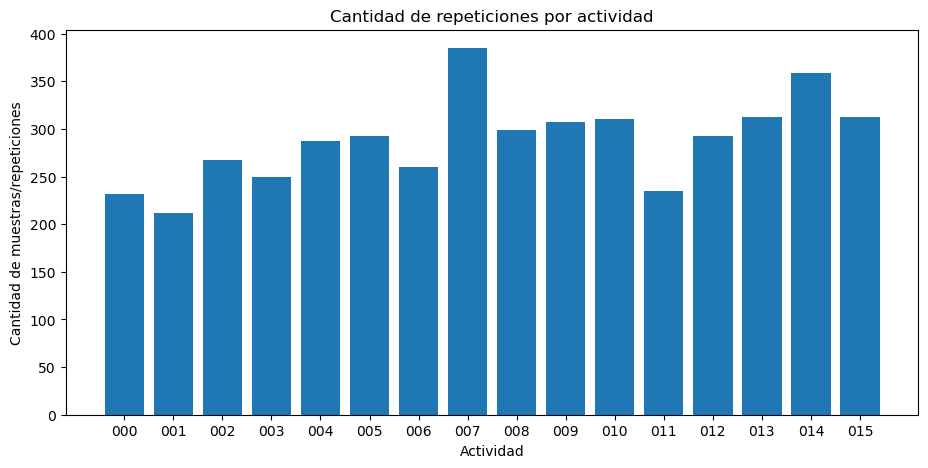

Total de repeticiones: 4616
Actividad con menos repeticiones: 001 - 212
Actividad con más repeticiones: 007 - 385


In [87]:
# Se usa sensor 2 porque sus archivos son válidos para las 16 actividades.
conteos = (
    inventario.query("sensor == '2' and estado == 'correcto'")
    .sort_values("actividad")
    .set_index("actividad")["repeticiones"]
    .astype(int)
)

display(conteos.rename("repeticiones").to_frame())

plt.figure(figsize=(11, 5))
plt.bar(conteos.index, conteos.values)
plt.xlabel("Actividad")
plt.ylabel("Cantidad de muestras/repeticiones")
plt.title("Cantidad de repeticiones por actividad")
plt.show()

print("Total de repeticiones:", conteos.sum())
print("Actividad con menos repeticiones:", conteos.idxmin(), "-", conteos.min())
print("Actividad con más repeticiones:", conteos.idxmax(), "-", conteos.max())

La gráfica muestra que las actividades no tienen exactamente la misma cantidad de repeticiones. La actividad 001 es la menos representada, con 212 repeticiones, mientras que la actividad 007 es la más representada, con 385. En total se dispone de 4,616 repeticiones en el sensor 2.

El desbalance no es extremo, pero debe considerarse al preparar el modelo. La división entre entrenamiento y prueba deberá ser estratificada para conservar una proporción semejante de cada actividad. También será preferible evaluar el clasificador con métricas por clase, y no solamente con exactitud global, para comprobar que reconozca tanto las actividades frecuentes como las menos frecuentes.

# Paso 2. Evaluación y visualización de variables

En este paso se hace primero un análisis **univariado**, observando canales por separado. Después se hace un análisis **multivariado** sencillo para revisar relaciones entre dos o más variables.

## 6. Análisis univariado: señal de una repetición

El primer acercamiento a los valores del sensor consiste en observar una sola repetición y un solo canal. Esta gráfica ayuda a entender cómo cambia la señal a lo largo del tiempo y a identificar visualmente cambios bruscos o periodos sin movimiento.

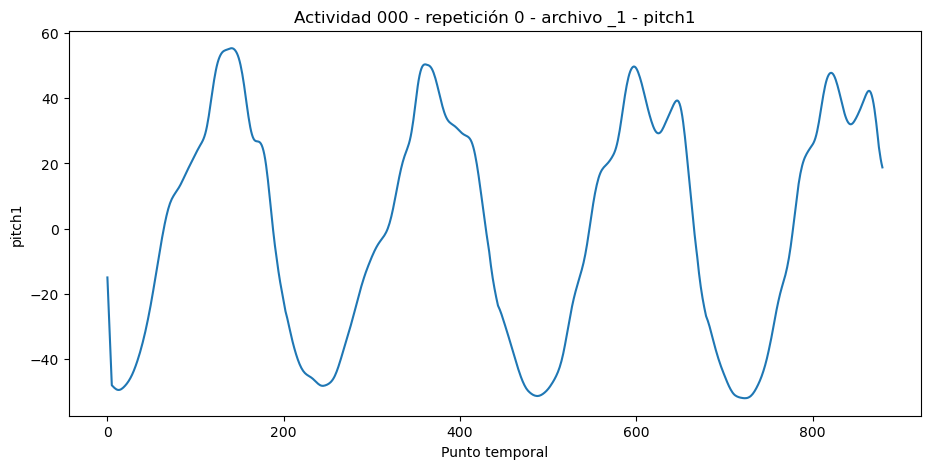

In [88]:
actividad_elegida = "000"
sensor_elegido = "1"
repeticion_elegida = 0
canal_elegido = 0
nombre_canal = channel_names[sensor_elegido][canal_elegido]

repeticion = datos[(actividad_elegida, sensor_elegido)][repeticion_elegida]

plt.figure(figsize=(11, 5))
plt.plot(repeticion[:, canal_elegido], color=colores_canales[canal_elegido])
plt.xlabel("Punto temporal")
plt.ylabel(nombre_canal)
plt.title(f"Actividad 000 - repetición 0 - archivo _1 - {nombre_canal}")
plt.show()

Esta gráfica permite observar cómo cambia una medición durante una repetición. El eje horizontal representa el tiempo mediante los 880 puntos temporales y el eje vertical muestra el valor registrado por el canal seleccionado.

La señal no es constante y presenta cambios a lo largo de la ejecución, lo cual confirma que el orden temporal contiene información. Para el futuro clasificador no bastará necesariamente con resumir toda la repetición mediante una sola media: también podrían ser útiles la variación, los máximos, los mínimos y la evolución de la señal en el tiempo.

## 7. Media, mediana y dispersión por actividad

Después de observar una señal individual, se resumen todos los valores de `f1` (posición 0 del archivo `_2`) para cada actividad. La media, mediana, desviación estándar, mínimo y máximo permiten comparar de manera sencilla el centro y la variabilidad de los movimientos.

In [89]:
# Para incluir las 16 actividades se utiliza f1 del archivo _2.
resumen_actividades = []
valores_por_actividad = {}

for numero in range(16):
    actividad = f"{numero:03d}"
    valores = datos[(actividad, "2")][:, :, 0].ravel()
    valores_por_actividad[actividad] = valores
    resumen_actividades.append({
        "actividad": actividad,
        "media": np.mean(valores),
        "mediana": np.median(valores),
        "desviacion_estandar": np.std(valores),
        "minimo": np.min(valores),
        "maximo": np.max(valores),
    })

resumen_actividades = pd.DataFrame(resumen_actividades).round(4)
display(resumen_actividades)

,actividad,media,mediana,desviacion_estandar,minimo,maximo
0,000,0.0,0.0653,7.4426,-61.6225,65.2690
1,001,0.0,0.1857,7.8184,-50.8678,79.4461
2,002,0.0,3.1670,15.4569,-95.9185,79.0574
3,003,0.0,-0.0202,7.6364,-39.8635,78.8211
4,004,0.0,0.7723,8.8588,-69.2864,29.7265
5,005,0.0,0.0000,9.8353,-75.0086,65.4894
6,006,0.0,0.7834,10.6749,-85.7750,81.8845
7,007,0.0,0.2011,13.5000,-105.7002,100.3866
8,008,-0.0,0.0852,7.0295,-102.2920,23.5447
9,009,-0.0,0.1477,11.6202,-109.3330,36.6307


La media y la mediana describen el centro de la distribución. En estos datos las medias son cercanas a cero, lo que es consistente con señales previamente centradas. Sin embargo, las medianas, desviaciones estándar y rangos sí cambian entre actividades.

Para clasificación, este resultado indica que la media por sí sola tendría poco poder de separación. La desviación estándar, los valores mínimo y máximo y otras medidas de variabilidad parecen más prometedoras porque presentan diferencias visibles entre movimientos. Estas medidas podrán convertirse posteriormente en características de entrada para un primer modelo sencillo.

## 8. Distribución de los canales

### Ejemplo inicial: comparación de dos actividades en un mismo histograma

Antes de comparar todos los canales, se presenta un ejemplo sencillo con `pitch1` del archivo `_1`. Se utilizan las actividades 000 y 001 y se colocan sus distribuciones en el mismo histograma.

Esta comparación permite observar directamente si los valores de un solo canal ocupan regiones diferentes según la actividad. Si las distribuciones estuvieran claramente separadas, `pitch1` podría ser útil por sí solo para distinguir estos dos movimientos. Si se traslapan, sería necesario combinarlo con otras mediciones.

Se utiliza densidad en el eje vertical para comparar la forma de las distribuciones sin que la diferencia en el número de repeticiones favorezca a una actividad.

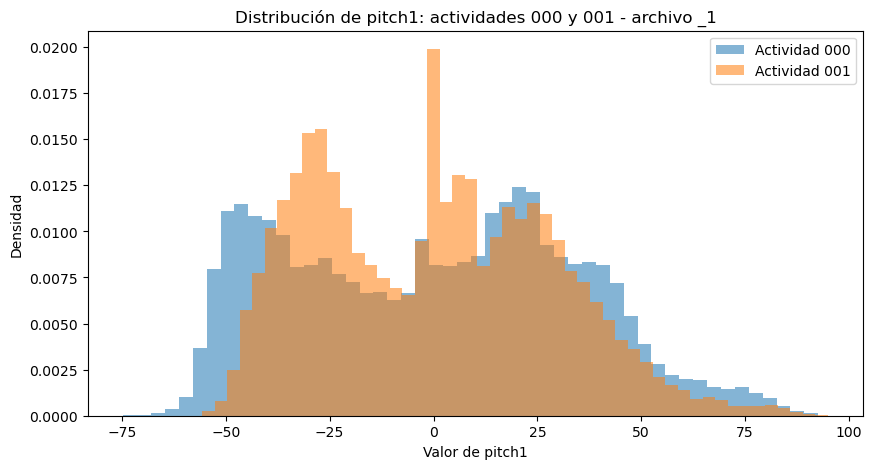

In [90]:
# Se seleccionan dos actividades, el archivo _1 y el canal pitch1.
actividad_a = "000"
actividad_b = "001"
sensor_ejemplo = "1"
canal_ejemplo = "pitch1"

# Se obtiene la posición de pitch1 dentro de los seis canales de _1.
indice_canal = channel_names[sensor_ejemplo].index(canal_ejemplo)

# Se concatenan todos los valores temporales de todas las repeticiones.
valores_a = datos[(actividad_a, sensor_ejemplo)][:, :, indice_canal].ravel()
valores_b = datos[(actividad_b, sensor_ejemplo)][:, :, indice_canal].ravel()

# Se dibujan ambas distribuciones en la misma figura.
plt.figure(figsize=(10, 5))
plt.hist(
    valores_a,
    bins=50,
    density=True,
    alpha=0.55,
    color="tab:blue",
    label=f"Actividad {actividad_a}",
)
plt.hist(
    valores_b,
    bins=50,
    density=True,
    alpha=0.55,
    color="tab:orange",
    label=f"Actividad {actividad_b}",
)
plt.xlabel("Valor de pitch1")
plt.ylabel("Densidad")
plt.title("Distribución de pitch1: actividades 000 y 001 - archivo _1")
plt.legend()
plt.show()

### Interpretación del ejemplo

Las distribuciones de las actividades 000 y 001 presentan un traslape considerable. Aunque existen diferencias en su forma y dispersión, muchos valores de `pitch1` aparecen en ambas actividades. Por lo tanto, una observación aislada de este canal no permitiría identificar con seguridad a cuál de los dos movimientos pertenece.

Esto no significa que `pitch1` sea inútil. Su comportamiento podría aportar información al combinarse con `yaw1`, `roll1` y los demás canales, o al resumirse mediante características como desviación estándar, rango y máximos. El resultado justifica ampliar el análisis en el siguiente bloque.

### Ampliación a los seis canales, actividades y sensores

### ¿Qué se hará y por qué?

El análisis anterior del primer canal era útil como ejemplo, pero no permitía conocer el comportamiento del resto de las mediciones. En este bloque se amplía la exploración a los **seis canales**, las **16 actividades** y los dos archivos de sensor (`_1` y `_2`).

Los canales no tienen los mismos nombres en ambos archivos:

- `_1`: `pitch1`, `yaw1`, `roll1`, `pitch2`, `yaw2` y `roll2`. *Pitch*, *yaw* y *roll* representan ángulos de orientación.
- `_2`: `f1`, `f2`, `f3`, `f4`, `f5` y `pitch3`. Los canales `f1` a `f5` corresponden a mediciones del guante y `pitch3` es una medición angular.

Se asigna un color fijo a cada posición. Por ejemplo, `pitch1` y `f1` aparecen en azul porque ambos ocupan la posición 0. Esto mantiene consistencia visual entre `_1` y `_2`, pero **no significa que `pitch1` y `f1` representen la misma variable física**.

Para cada combinación de sensor y canal se genera una cuadrícula de 4 × 4. Cada recuadro contiene el histograma de una actividad. En total se producen 12 figuras: seis canales para `_1` y seis para `_2`. En la cuadrícula de `_1`, la actividad 014 aparecerá como **sin datos** porque `014_1.npy` está dañado.

Los histogramas permiten comparar tres propiedades:

- **Centro:** zona donde se concentra la mayor parte de los valores.
- **Dispersión:** qué tan extendida está la distribución.
- **Forma:** presencia de asimetría, varios picos o colas largas.

Se utiliza la misma escala horizontal para un mismo canal en `_1` y `_2`. Así, una distribución más ancha representa realmente una mayor dispersión y no un cambio automático de escala. Los ejes verticales muestran densidad en lugar del conteo bruto, porque las actividades tienen diferentes cantidades de repeticiones. De esta manera se compara la forma de la distribución sin favorecer a las actividades con más muestras.

Para que el cálculo de las gráficas sea manejable, se toma un valor de cada 20 puntos. La selección es uniforme y solo se utiliza para visualizar; las tablas estadísticas se calculan con todos los valores disponibles.

In [91]:
# Se guardará una fila de resumen por actividad, sensor y canal.
resumen_canales = []

# Este diccionario guardará los límites comunes de cada canal.
# Los límites se calculan usando ambos sensores para hacer comparables las gráficas.
limites_canales = {}

for canal in range(6):
    valores_del_canal = []

    # Se reúnen valores del canal actual en todos los archivos válidos.
    for arreglo in datos.values():
        valores_del_canal.append(arreglo[:, :, canal].ravel()[::20])

    valores_del_canal = np.concatenate(valores_del_canal)

    # Se usan los percentiles 1 y 99 para evitar que unos pocos extremos
    # hagan que la parte central de los histogramas sea difícil de observar.
    limites_canales[canal] = (
        np.percentile(valores_del_canal, 1),
        np.percentile(valores_del_canal, 99),
    )

# Se calculan estadísticas usando todos los valores, sin aplicar el muestreo gráfico.
for (actividad, sensor), arreglo in sorted(datos.items()):
    for canal in range(6):
        valores = arreglo[:, :, canal].ravel()
        resumen_canales.append({
            "actividad": actividad,
            "sensor": sensor,
            "canal": canal,
            "nombre_canal": channel_names[sensor][canal],
            "media": np.mean(valores),
            "mediana": np.median(valores),
            "desviacion_estandar": np.std(valores),
            "minimo": np.min(valores),
            "maximo": np.max(valores),
        })

# La lista de resultados se convierte en una tabla.
resumen_canales = pd.DataFrame(resumen_canales)

# Se muestra una tabla de desviaciones estándar por separado para cada sensor.
# Las filas son actividades y las columnas representan los seis canales.
for sensor in ["1", "2"]:
    print(f"Desviación estándar por actividad y canal - archivo _{sensor}")
    tabla_dispersion = resumen_canales[resumen_canales["sensor"] == sensor].pivot(
        index="actividad",
        columns="nombre_canal",
        values="desviacion_estandar",
    )
    tabla_dispersion = tabla_dispersion[channel_names[sensor]]
    display(tabla_dispersion.round(2))

Desviación estándar por actividad y canal - archivo _1


nombre_canal,pitch1,yaw1,roll1,pitch2,yaw2,roll2
actividad,,,,,,
000,34.35,26.57,37.09,41.75,28.66,17.55
001,28.47,26.58,32.78,15.17,15.19,8.59
002,25.10,23.45,25.83,23.11,24.13,15.02
003,20.64,15.96,36.67,20.14,24.05,16.71
004,5.97,4.31,6.41,21.62,31.67,26.65
005,7.42,3.31,6.13,16.47,3.29,2.70
006,16.66,16.35,15.59,23.57,29.35,18.21
007,5.47,10.59,36.13,14.66,3.43,5.72
008,32.02,48.29,51.89,31.60,29.40,28.68


Desviación estándar por actividad y canal - archivo _2


nombre_canal,f1,f2,f3,f4,f5,pitch3
actividad,,,,,,
000,7.44,9.53,8.88,9.51,5.81,76.87
001,7.82,11.06,10.94,12.02,9.31,70.47
002,15.46,17.98,15.16,18.29,12.56,66.87
003,7.64,11.02,11.46,12.25,8.69,93.33
004,8.86,10.12,10.80,11.57,9.80,91.26
005,9.84,14.64,14.71,14.23,14.09,80.65
006,10.67,10.75,9.39,10.58,10.32,36.31
007,13.50,11.96,11.77,12.51,13.62,71.37
008,7.03,5.33,5.97,5.83,9.55,60.73


### ¿Qué muestra la tabla?

Cada fila representa una actividad y cada columna corresponde a uno de los seis canales, identificados por su nombre real. La desviación estándar indica cuánto cambian los valores alrededor de su media. Un valor grande representa una señal más variable; uno pequeño representa una señal más concentrada.

La tabla permite identificar qué canales cambian más en cada movimiento y comparar `_1` contra `_2`. Las diferencias de dispersión son relevantes para clasificación porque dos actividades con medias cercanas a cero todavía pueden distinguirse por la cantidad de variación presente en sus señales.

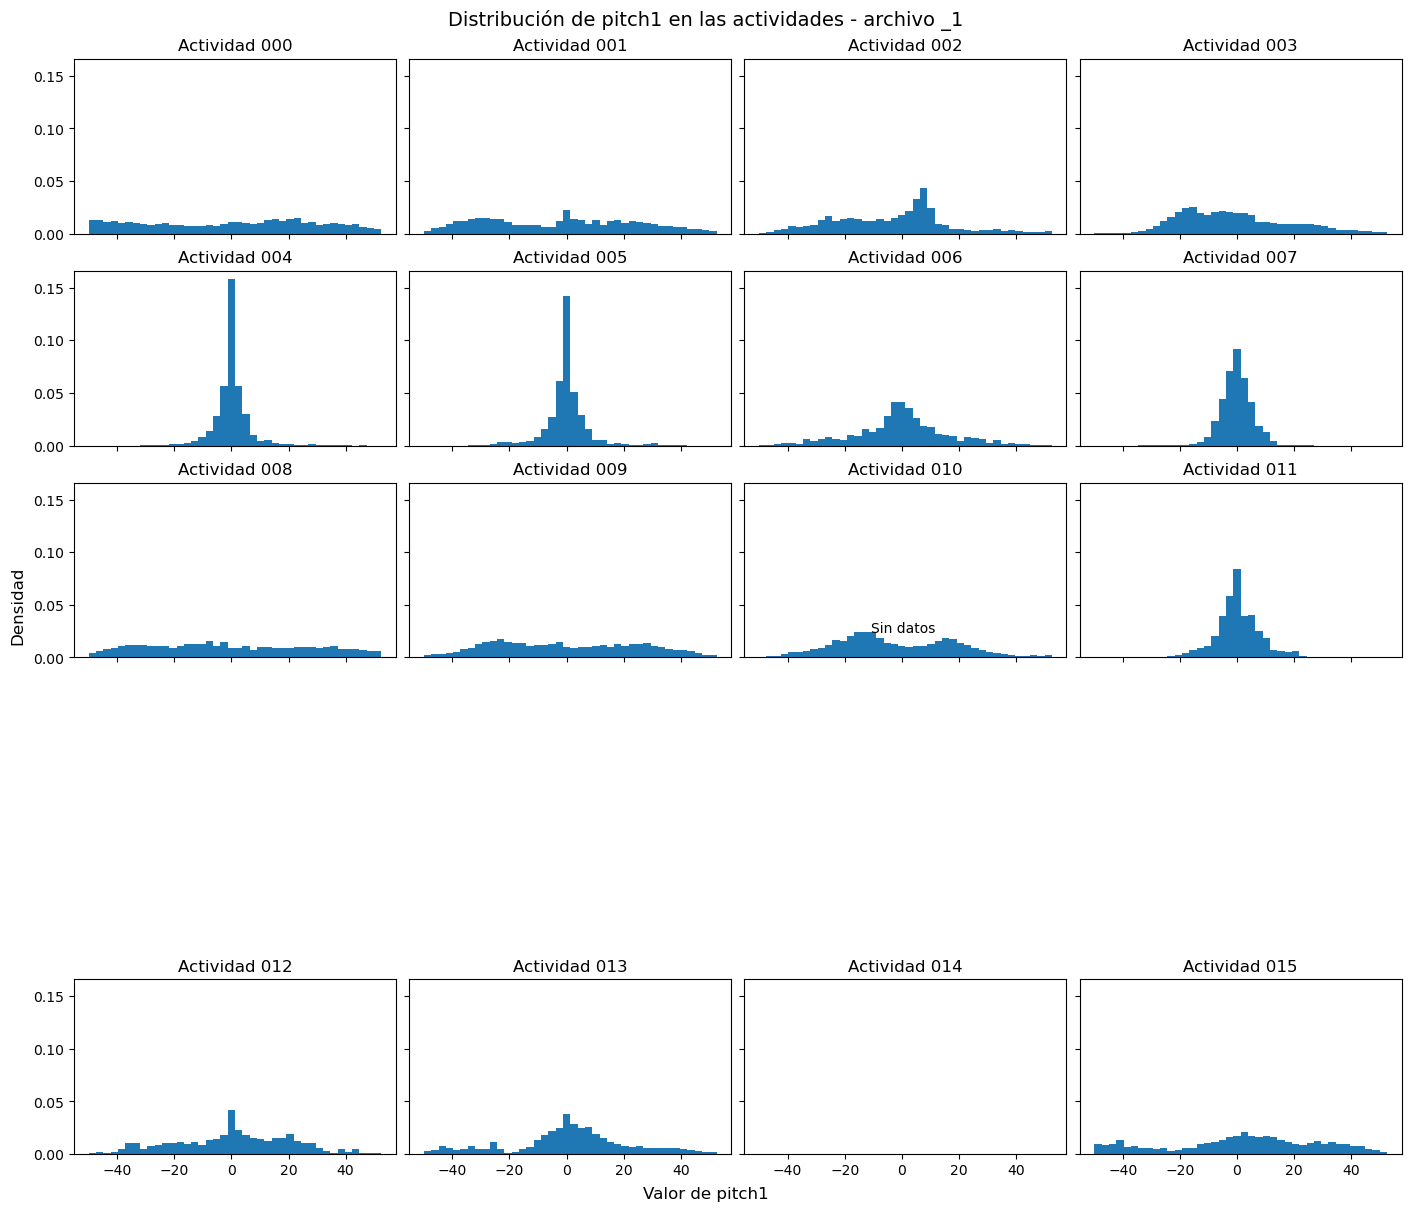

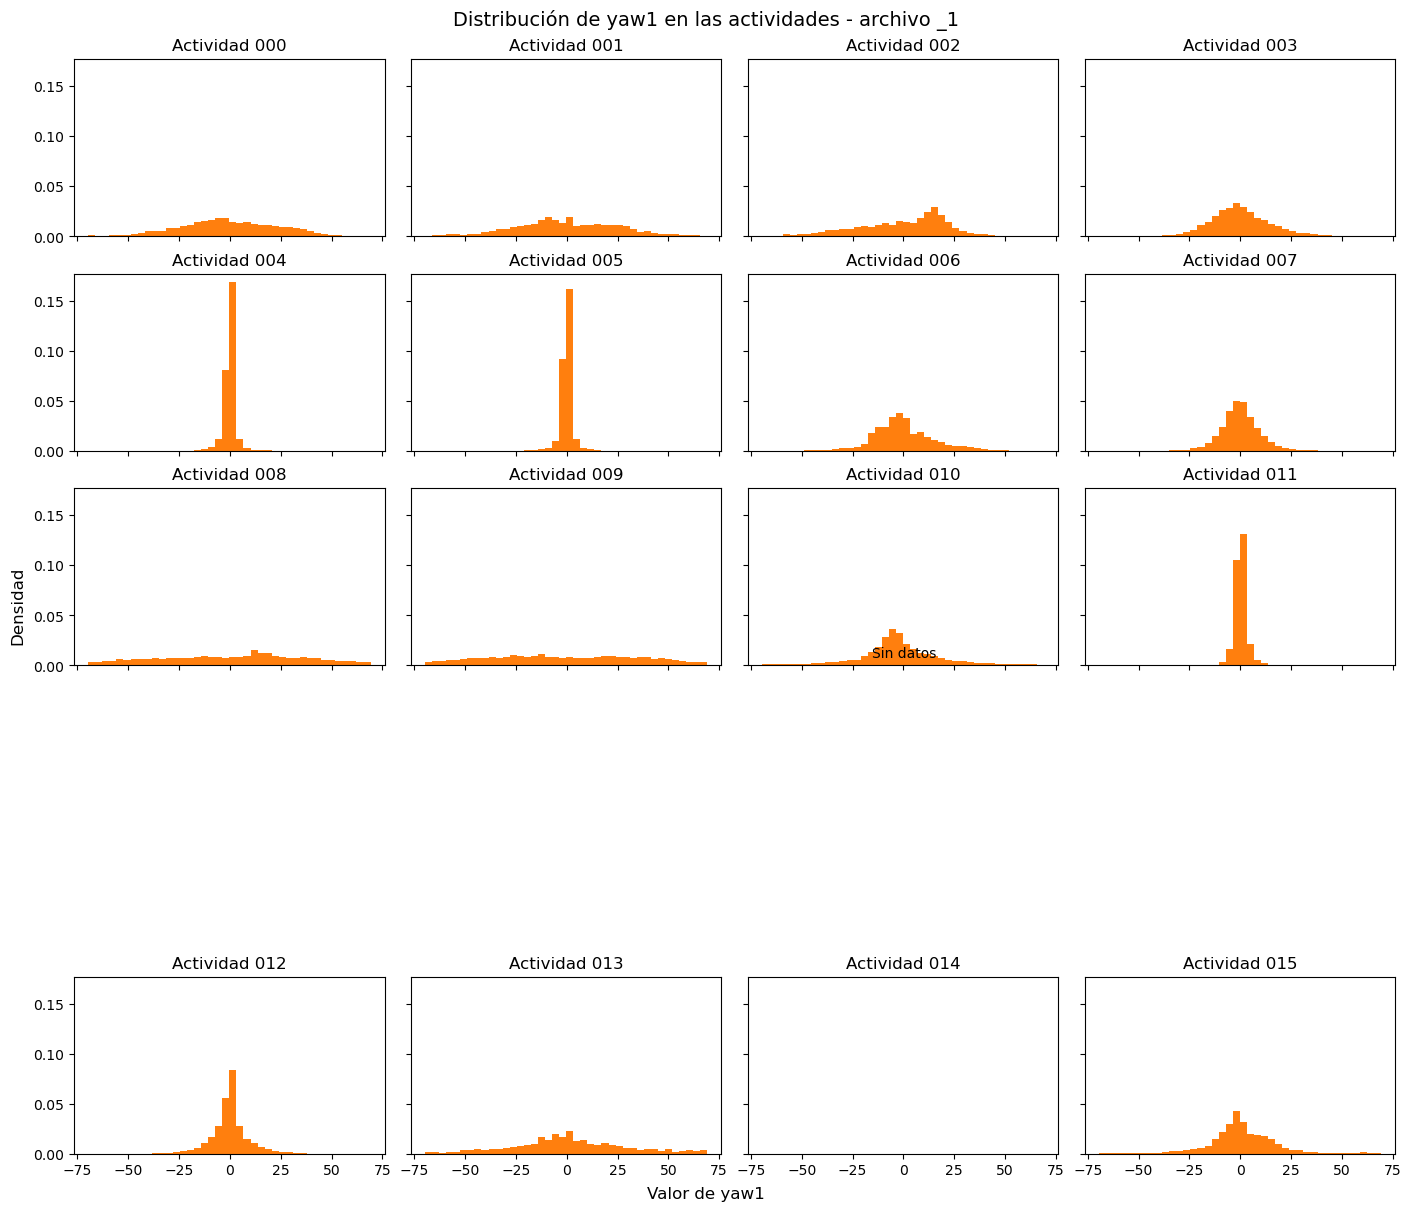

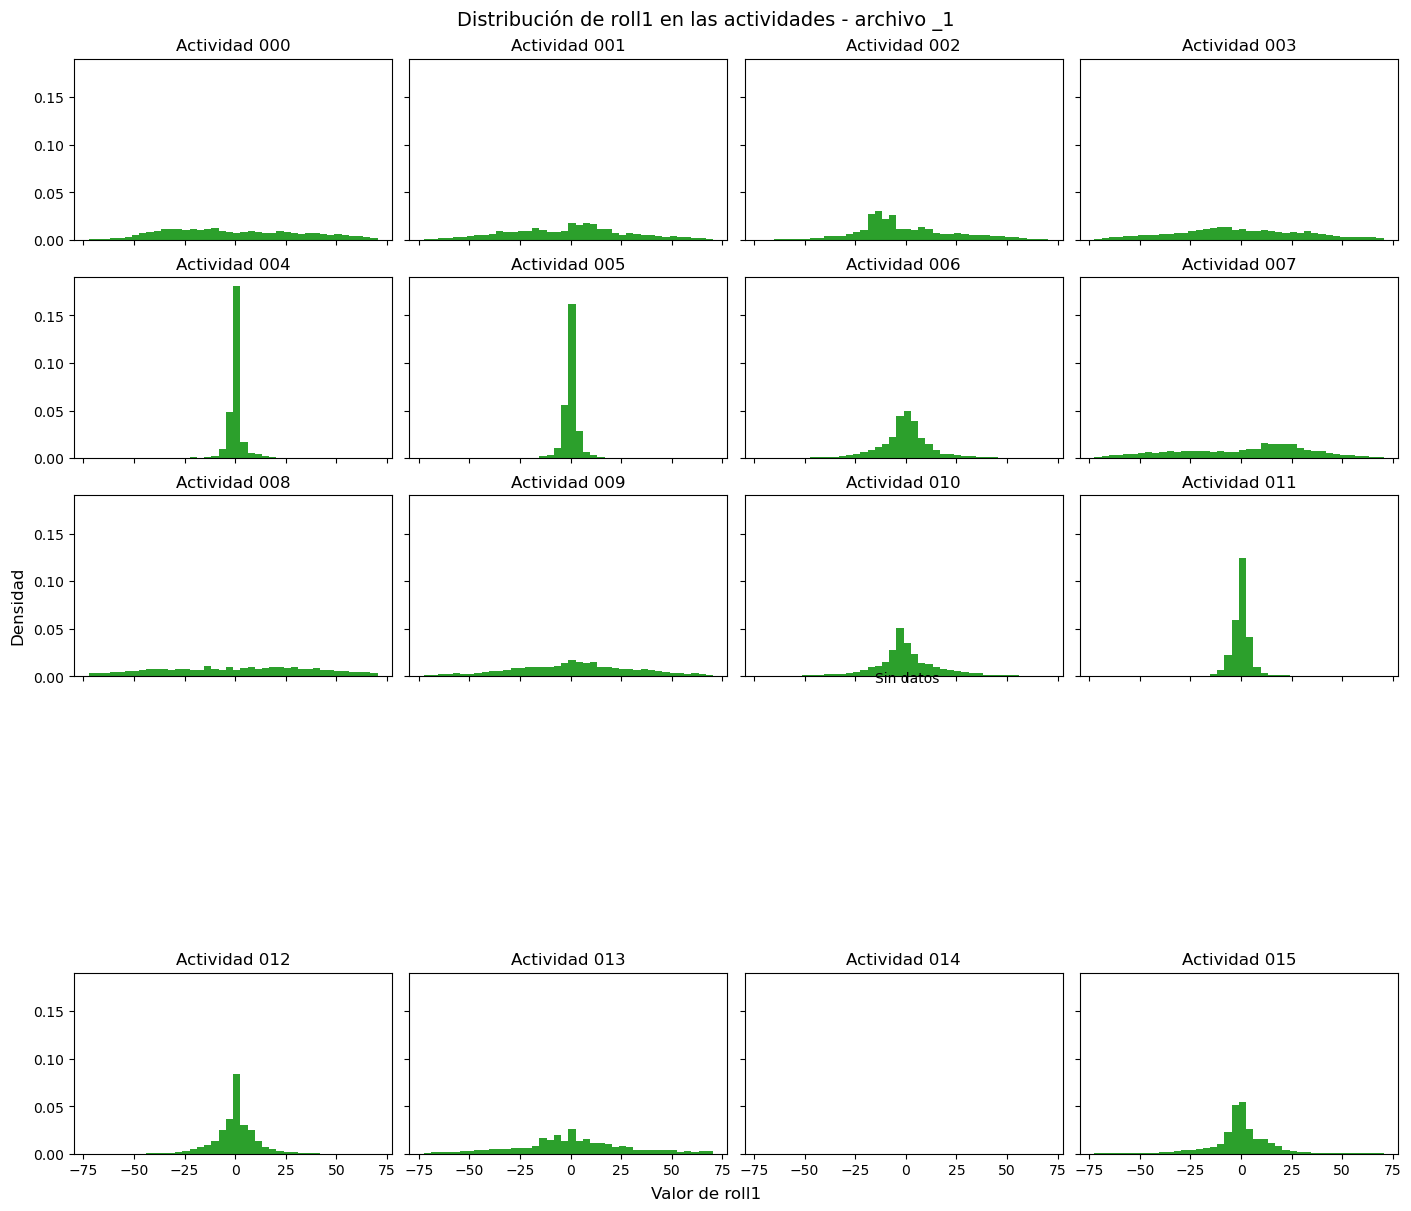

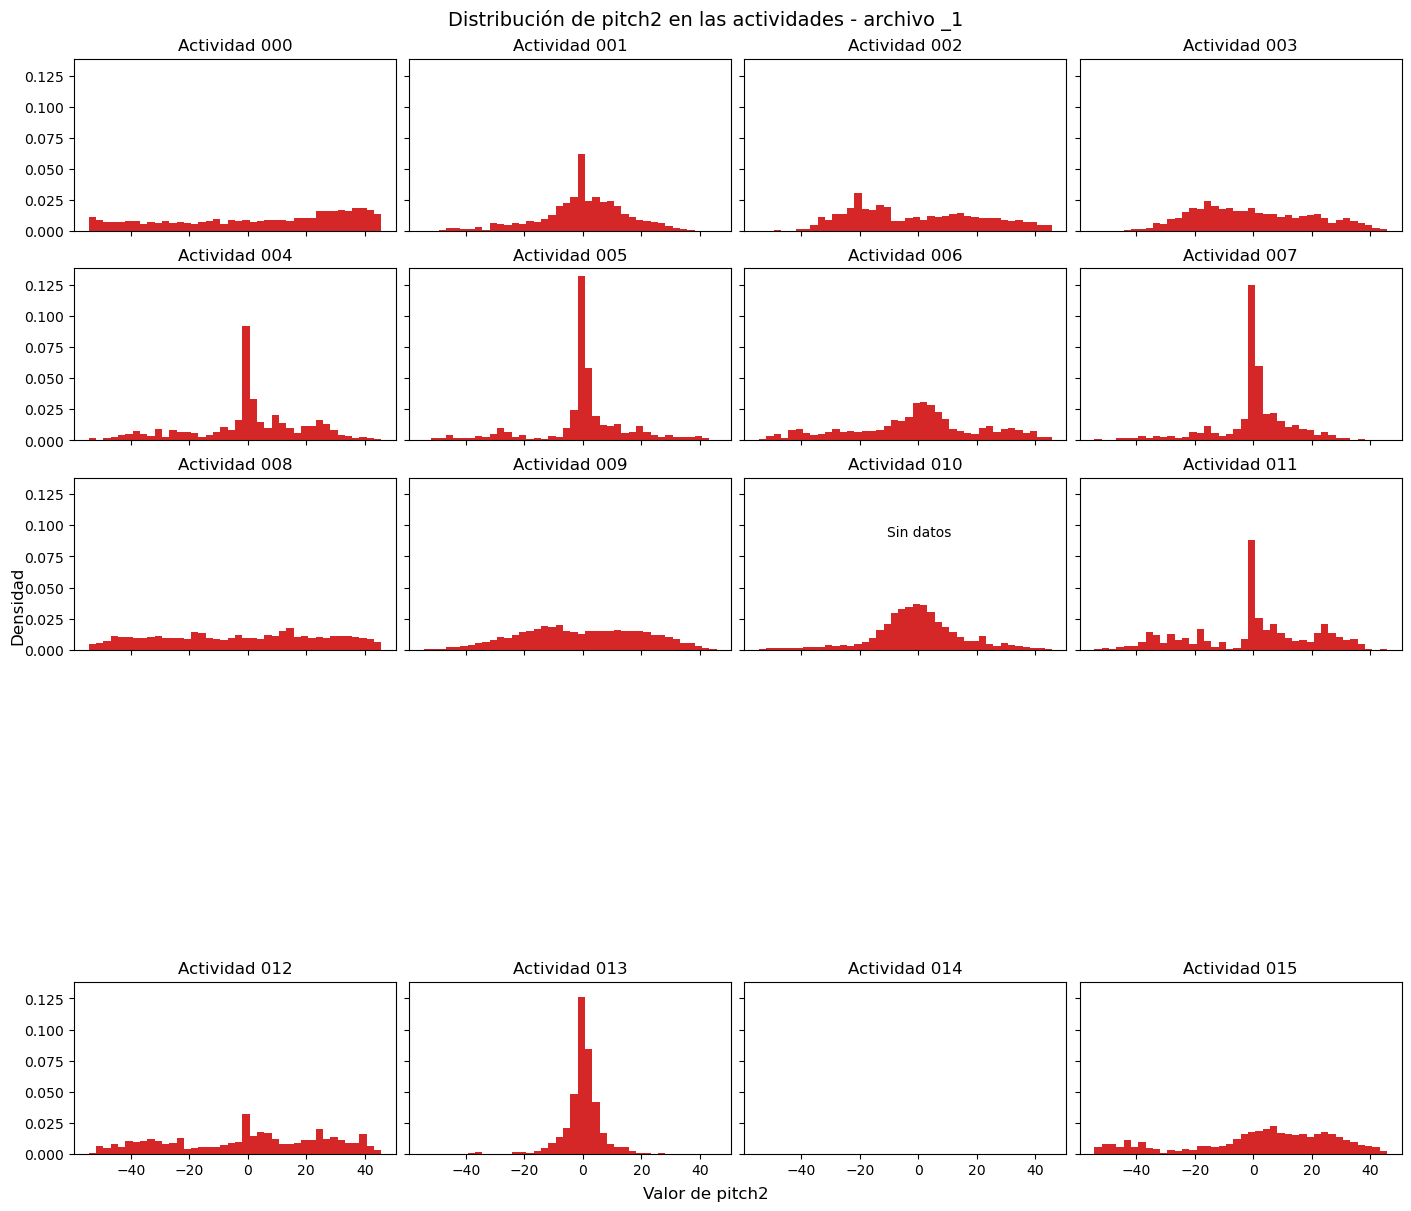

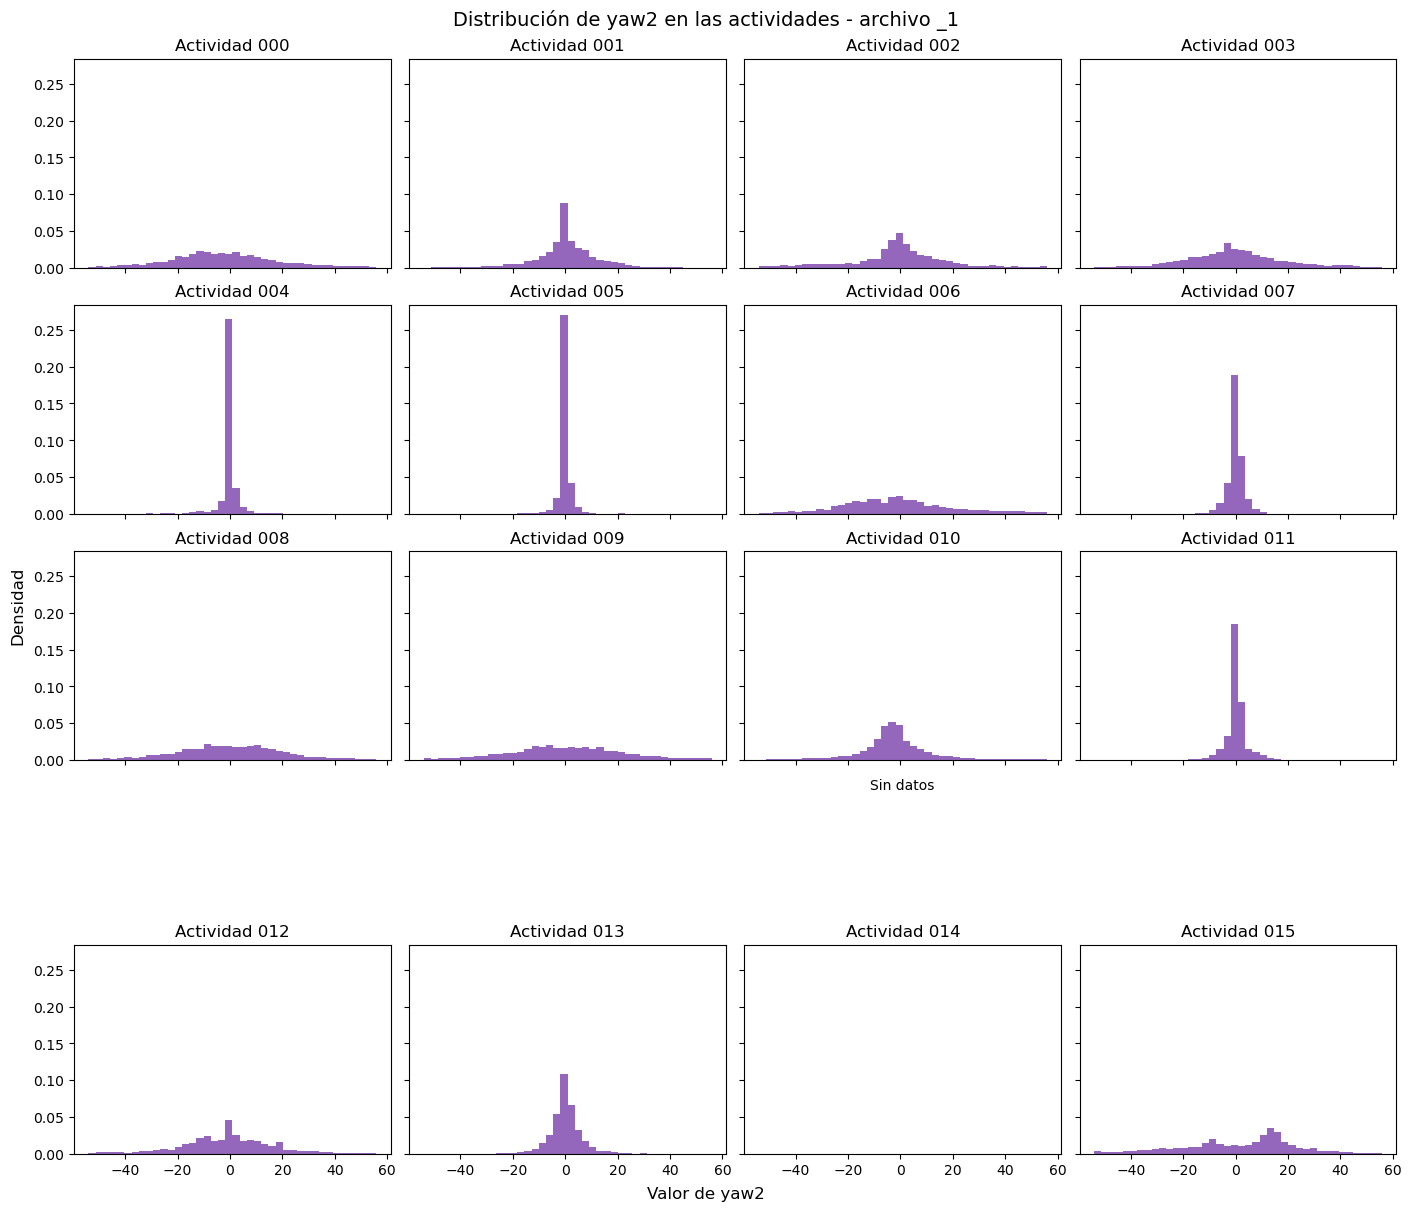

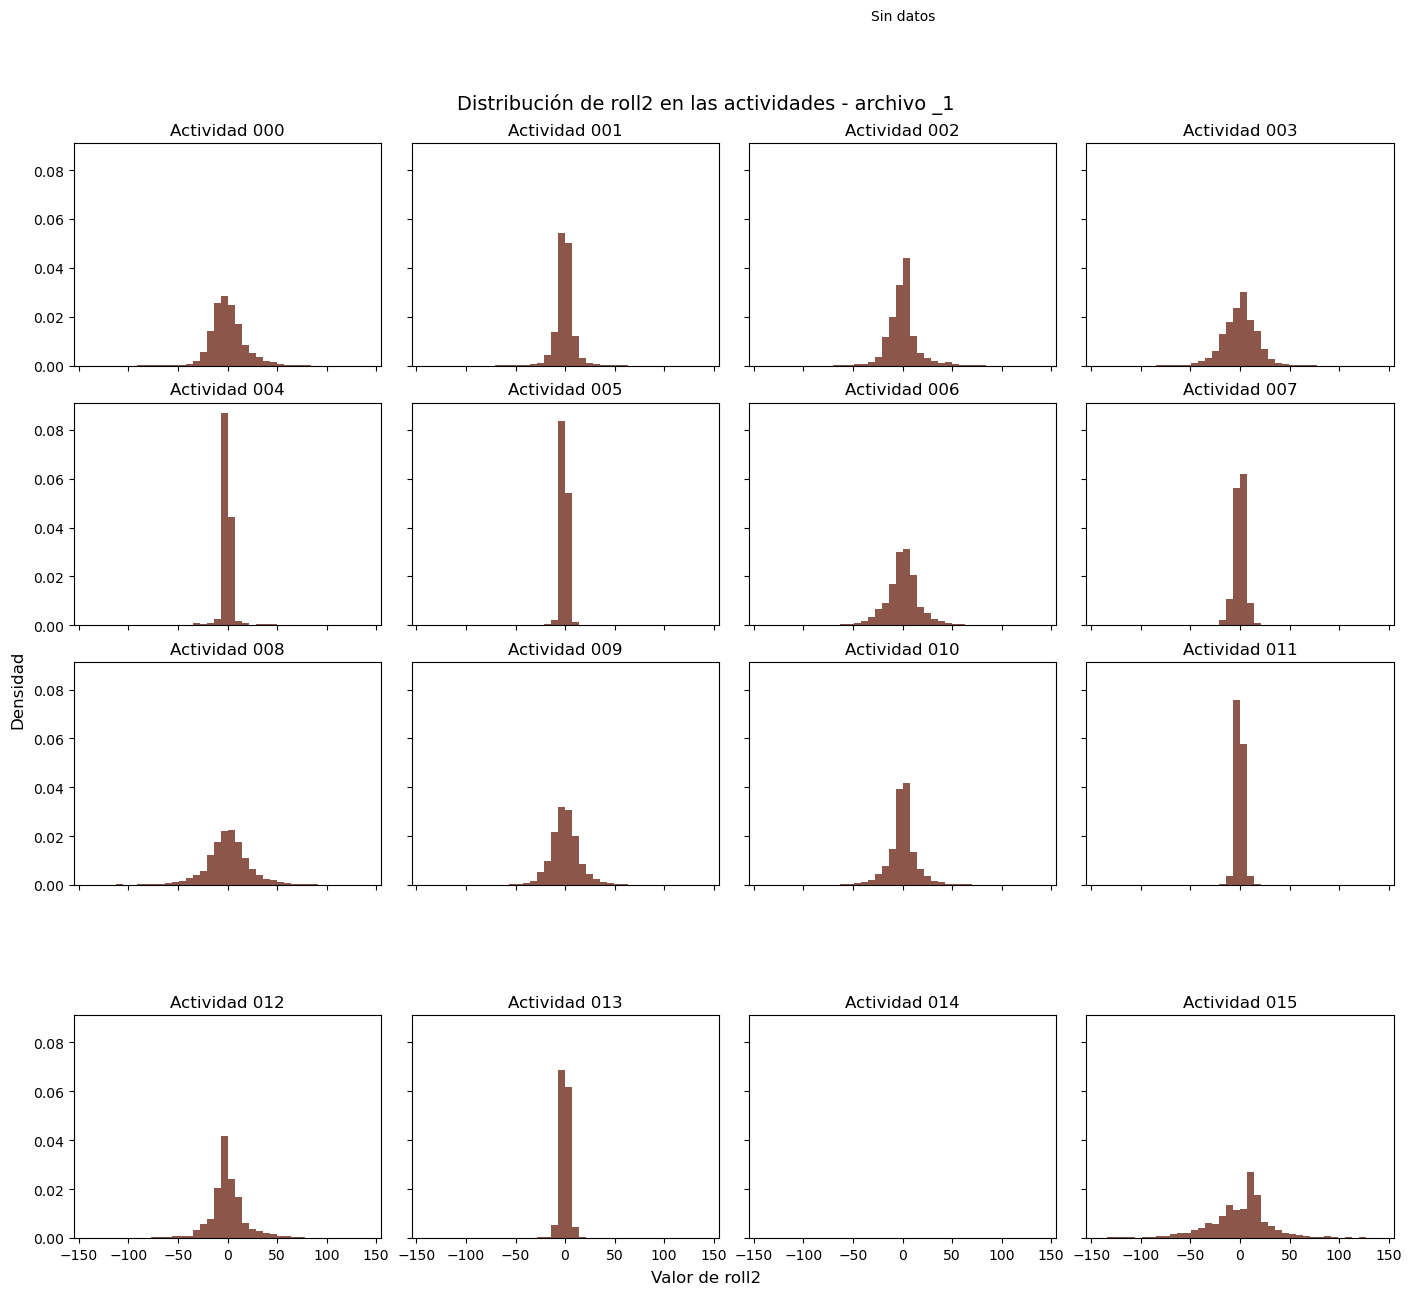

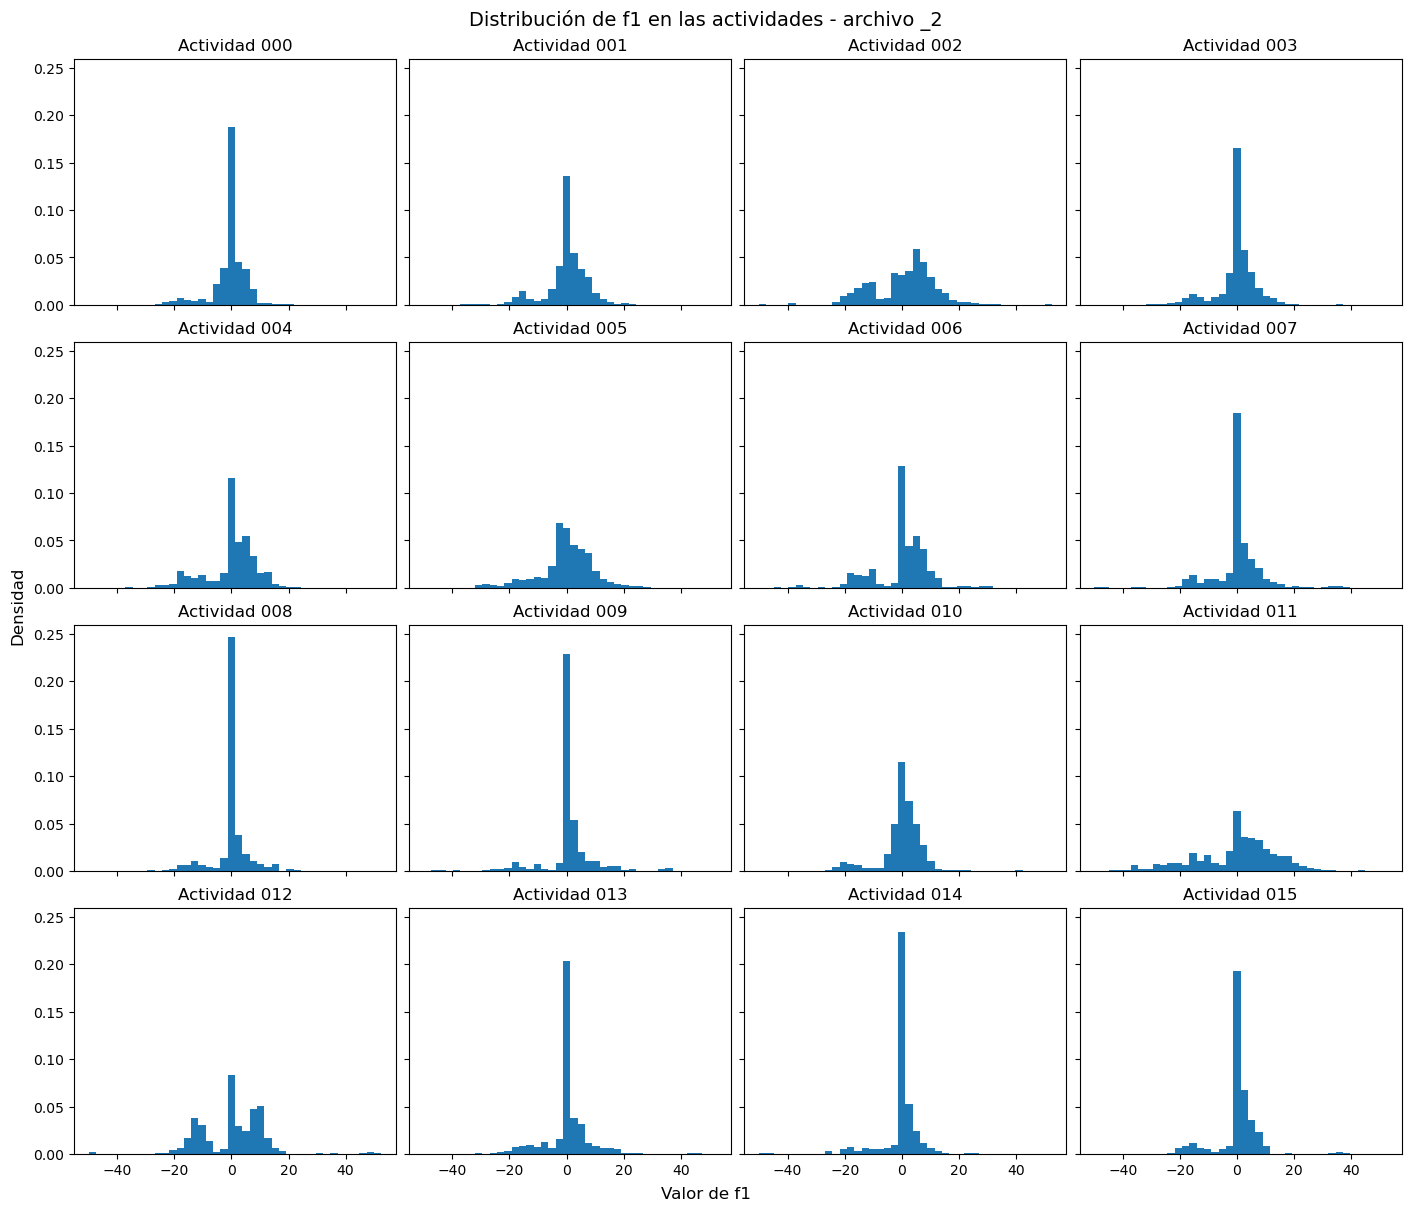

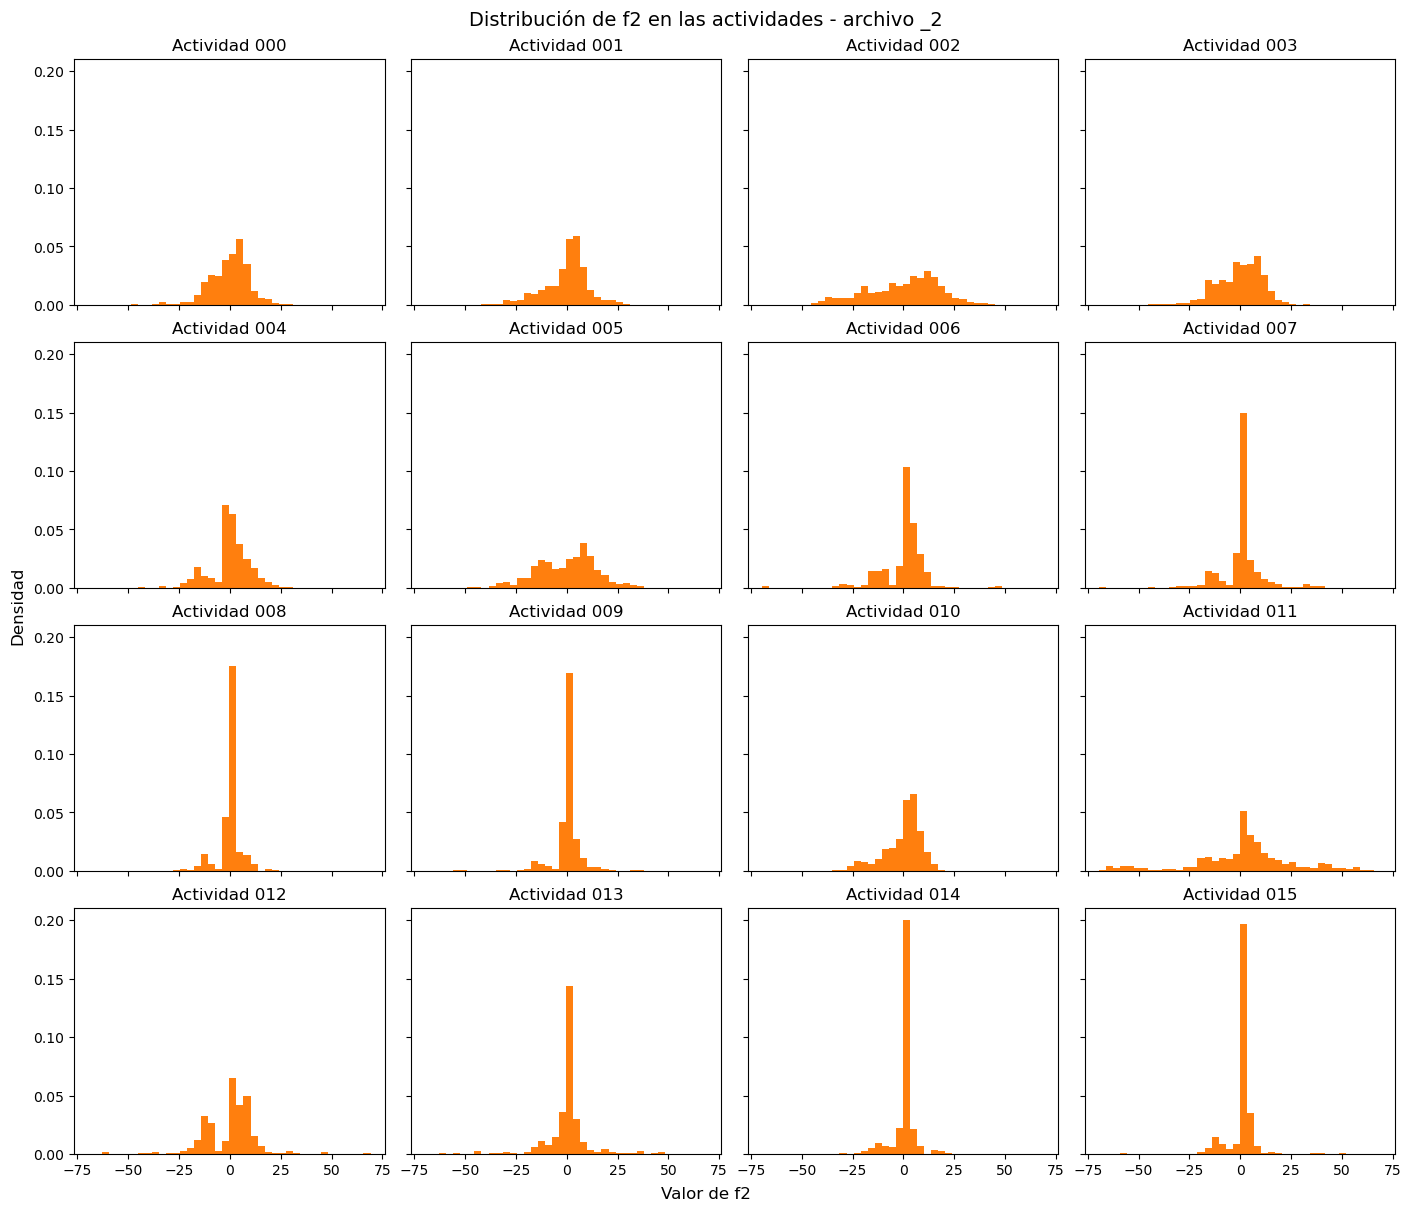

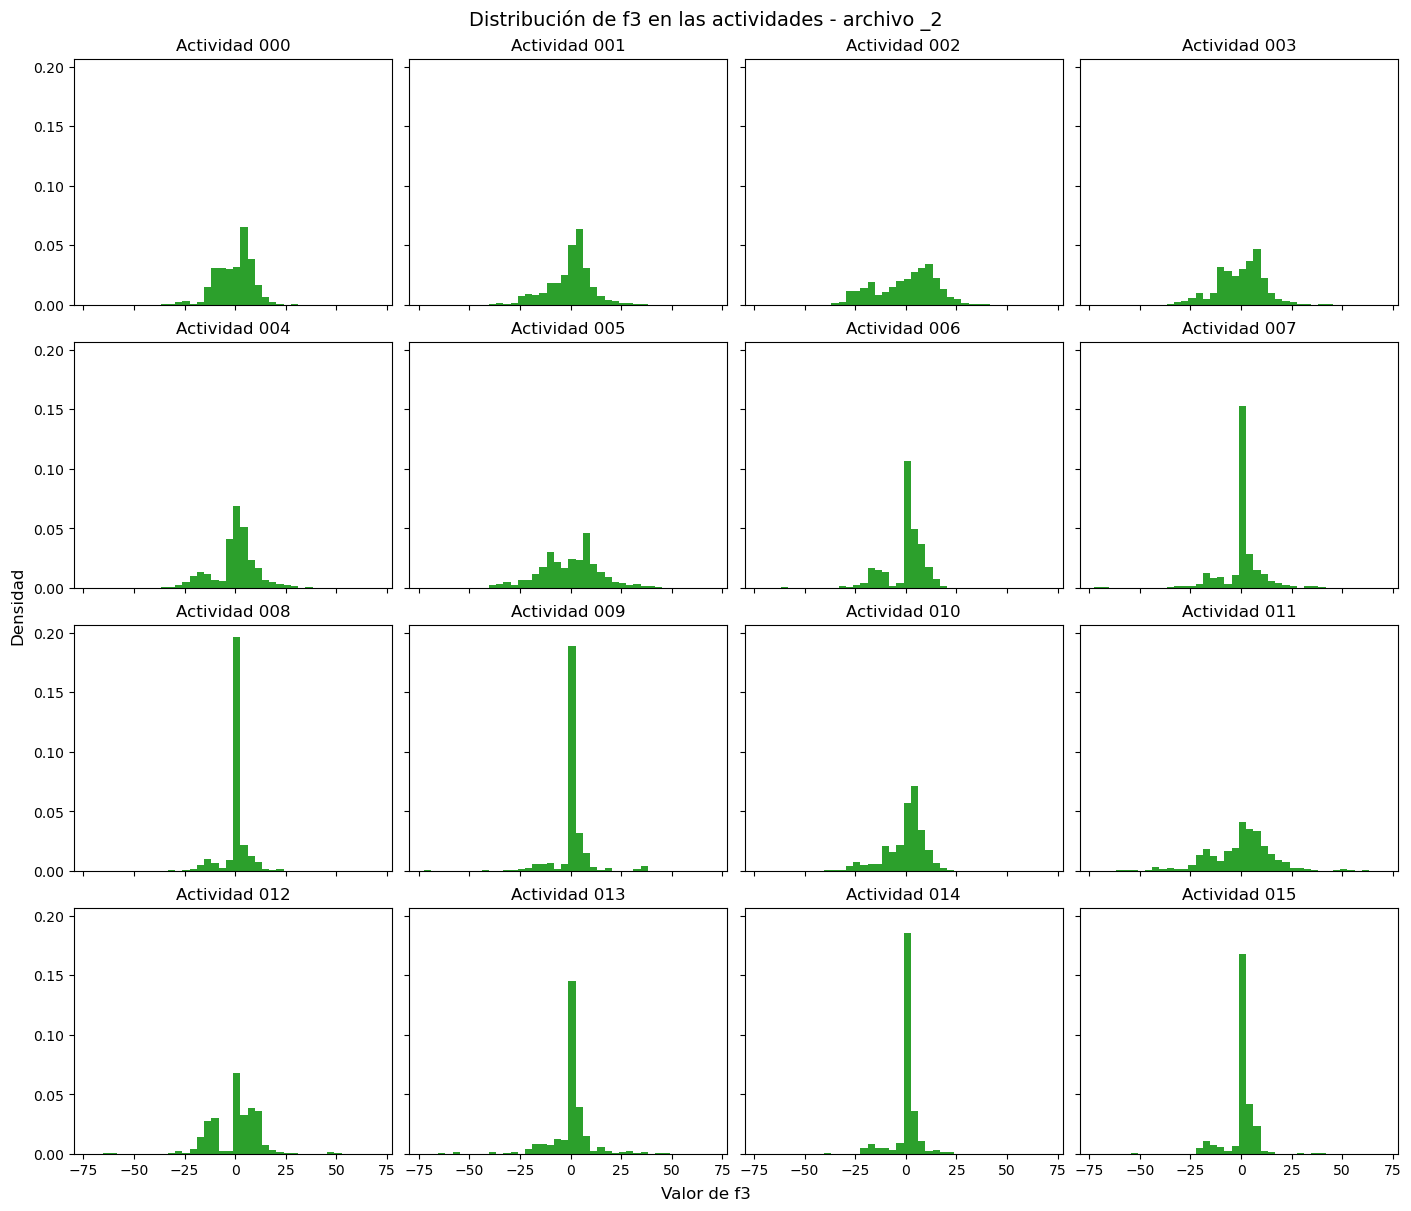

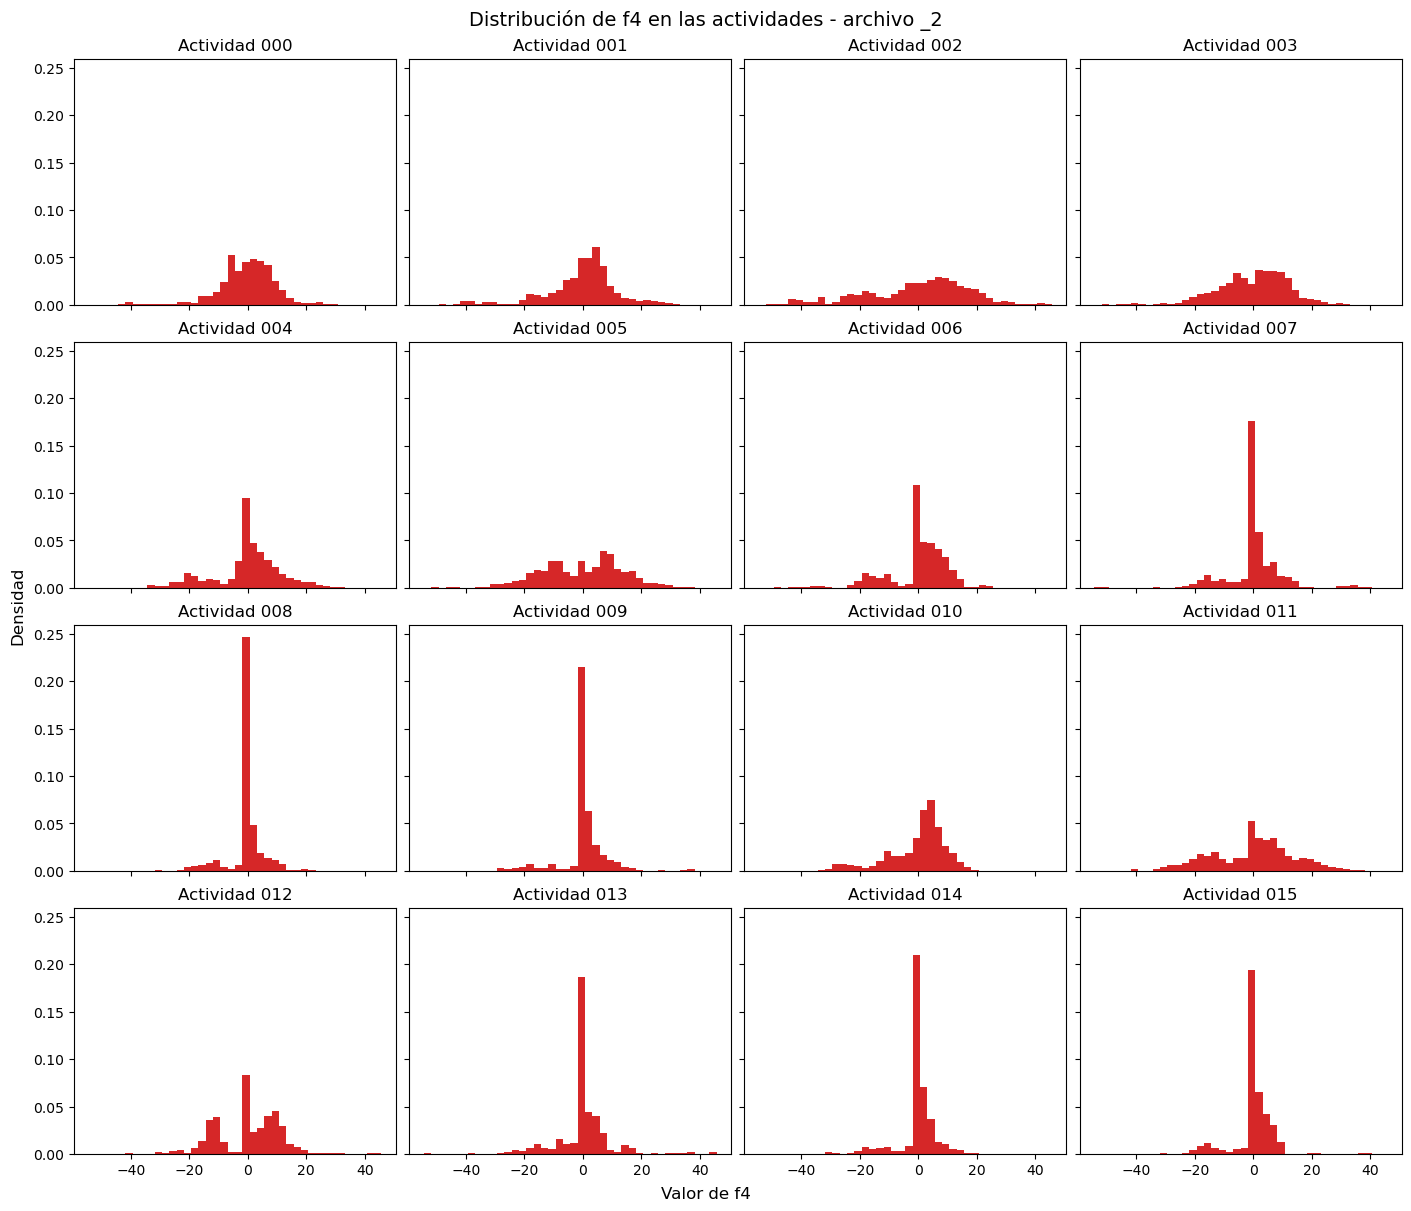

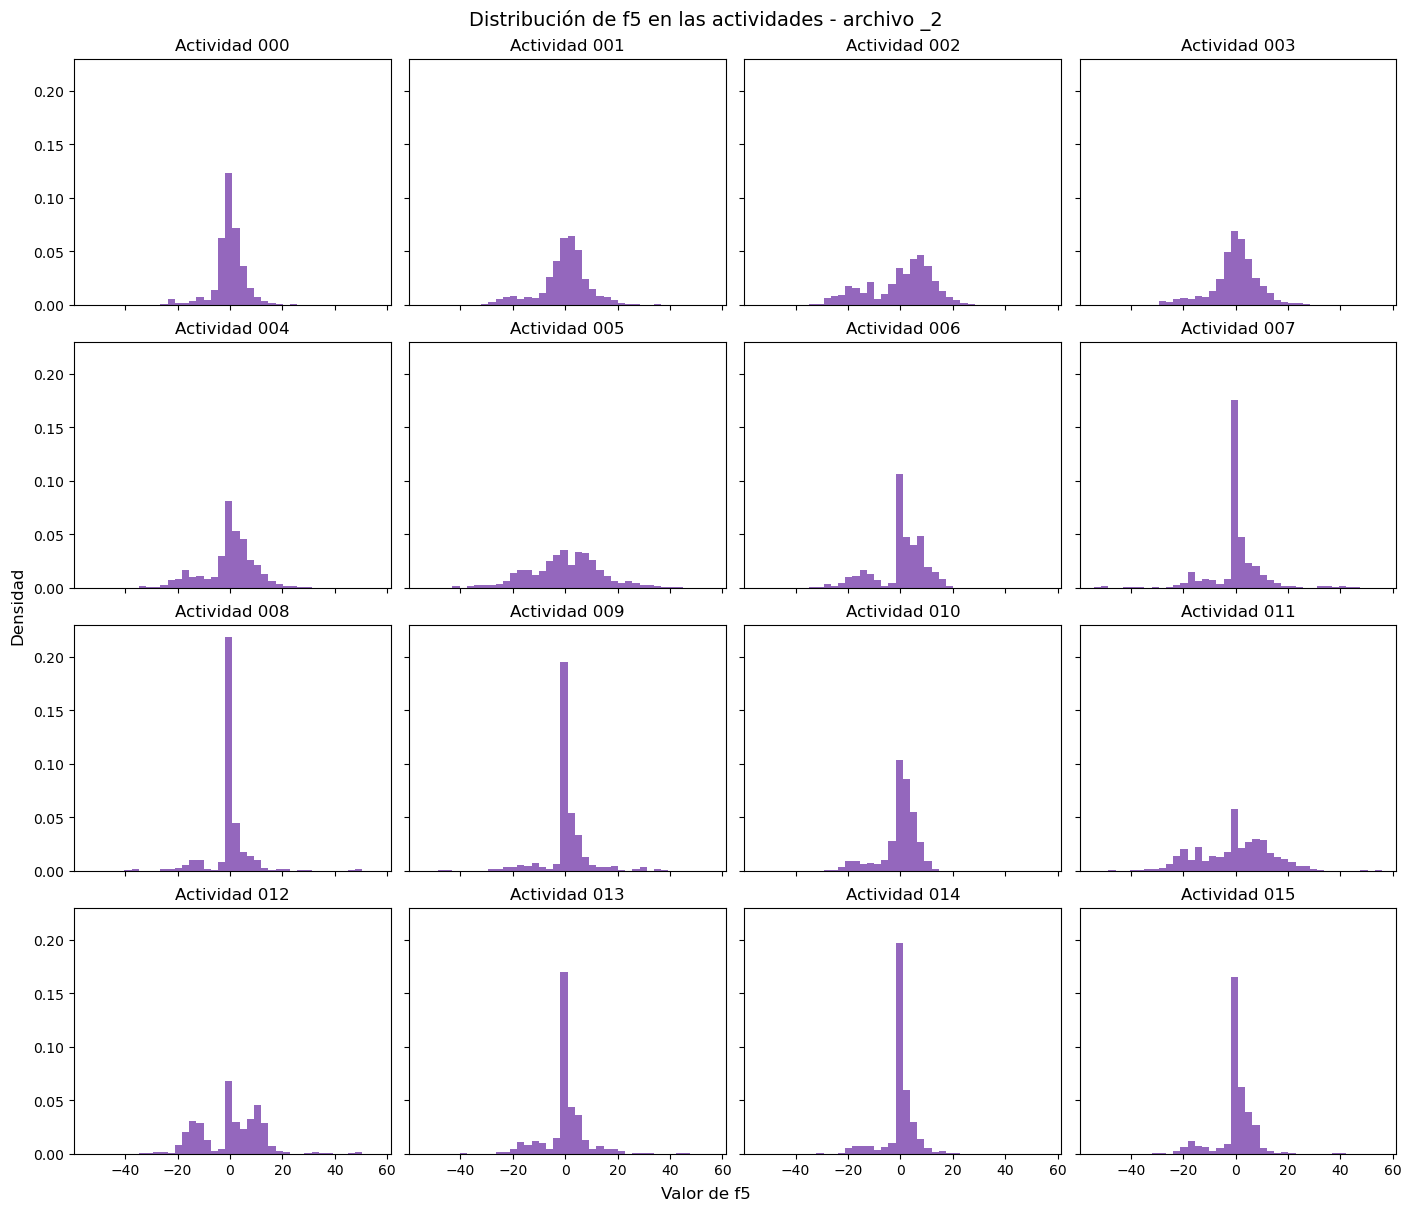

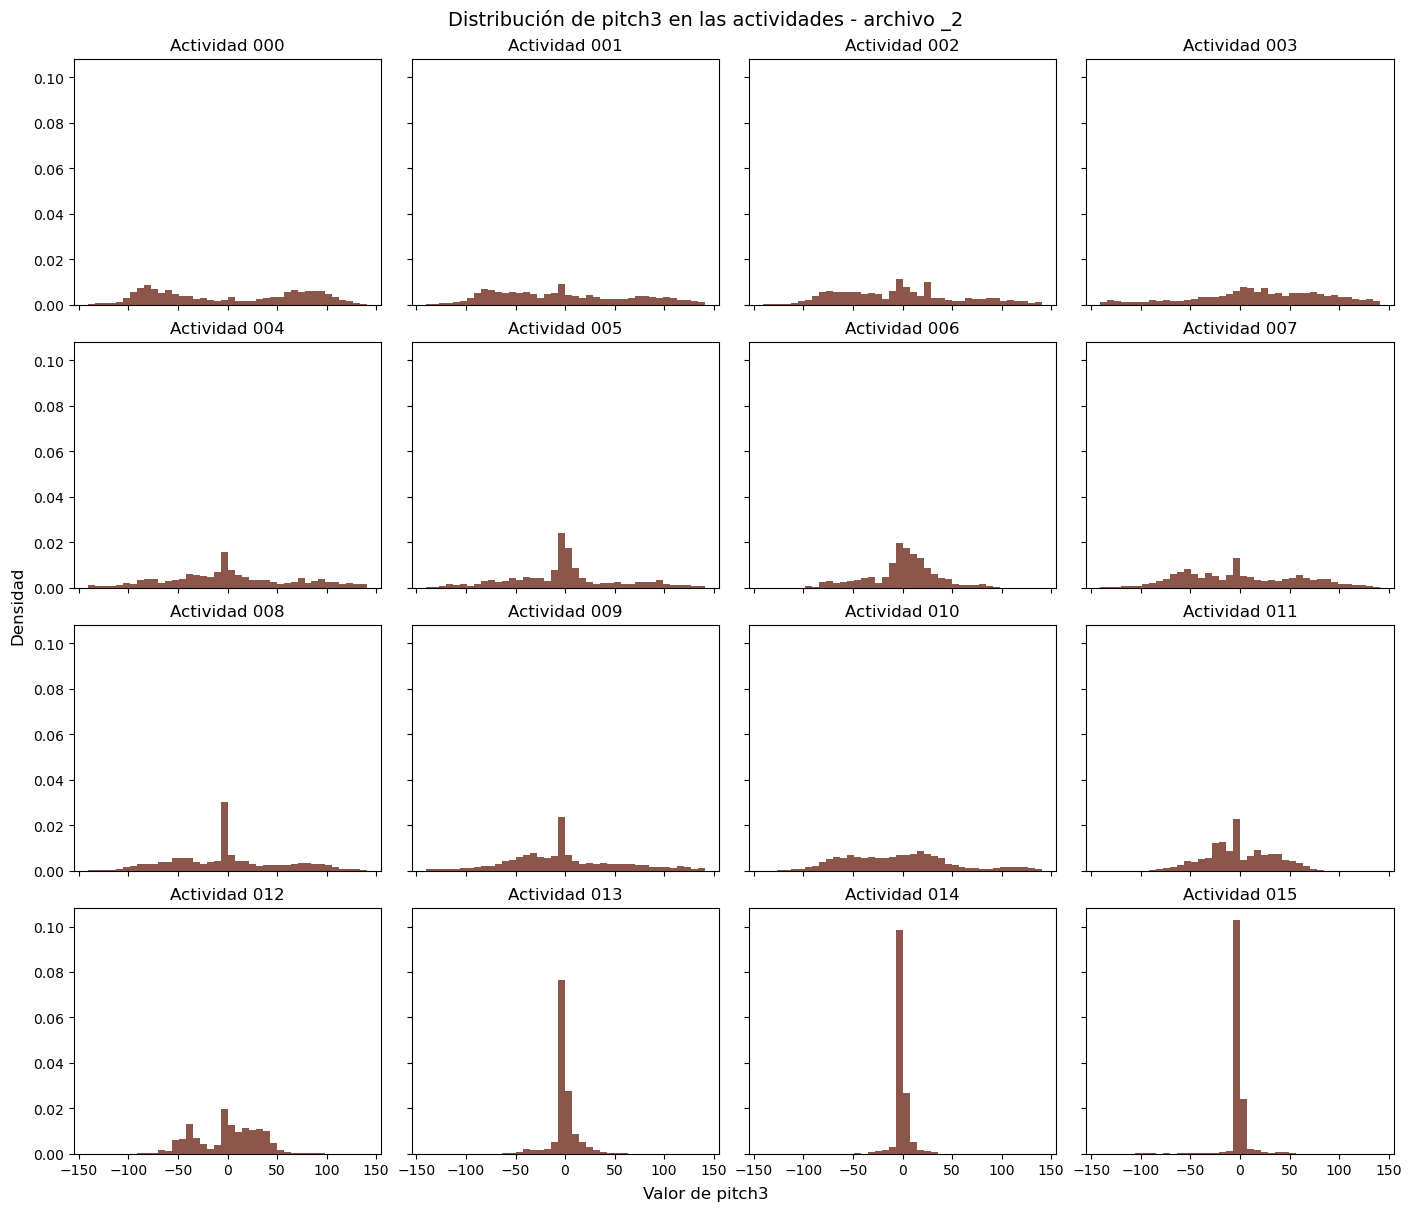

In [92]:
# Se construyen las gráficas por separado para cada sensor y cada canal.
for sensor in ["1", "2"]:
    for canal in range(6):

        # Se obtiene el nombre real del canal en el archivo actual.
        nombre_canal = channel_names[sensor][canal]

        # Todas las actividades del mismo canal usan los mismos límites.
        limite_inferior, limite_superior = limites_canales[canal]

        # Se crea una cuadrícula con espacio para las 16 actividades.
        fig, ejes = plt.subplots(
            4, 4, figsize=(14, 12), sharex=True, sharey=True, constrained_layout=True
        )

        for numero, eje in enumerate(ejes.flat):
            actividad = f"{numero:03d}"
            arreglo = datos.get((actividad, sensor))

            # Si el archivo no está disponible, se informa en la gráfica.
            if arreglo is None:
                eje.text(0.5, 0.5, "Sin datos", ha="center", va="center")
                eje.set_title(f"Actividad {actividad}")
                continue

            # Se extrae el canal y se toma un valor de cada 20 para la visualización.
            valores_grafica = arreglo[:, :, canal].ravel()[::20]

            # density=True permite comparar formas aunque cambie el número de repeticiones.
            eje.hist(
                valores_grafica,
                bins=40,
                range=(limite_inferior, limite_superior),
                density=True,
                color=colores_canales[canal],
            )
            eje.set_title(f"Actividad {actividad}")

        fig.supxlabel(f"Valor de {nombre_canal}")
        fig.supylabel("Densidad")
        fig.suptitle(
            f"Distribución de {nombre_canal} en las actividades - archivo _{sensor}",
            fontsize=14,
        )
        plt.show()

### Interpretación de las distribuciones

Las 12 figuras permiten observar que la separación entre actividades depende del canal y del archivo de sensor. En algunos canales ciertas actividades presentan distribuciones más anchas, colas más largas o concentraciones distintas. Estas diferencias respaldan el uso de características como desviación estándar, rango, mínimo, máximo y percentiles para construir un primer clasificador.

También se observa traslape en distintos pares de actividades. Por lo tanto, ningún histograma individual demuestra que un solo canal sea suficiente para identificar los 16 movimientos. El modelo deberá combinar información de varios canales. Además, dos actividades pueden tener histogramas parecidos y aun así diferir en el orden en que ocurre el movimiento; los histogramas describen la distribución de valores, pero no conservan el orden de los 880 puntos temporales.

Las figuras de `_1` y `_2` no deben mezclarse visualmente como si fueran una sola fuente. Las formas y dispersiones pueden cambiar entre ambos archivos, y `_1` no incluye la actividad 014. Este resultado refuerza que, antes de modelar, será necesario decidir entre tres alternativas: construir un modelo para `_1`, construir otro para `_2`, o combinar ambos únicamente después de comprobar que sus canales tienen significados compatibles y de recuperar el archivo dañado.

En términos del futuro modelo, este bloque sugiere comenzar con una tabla de características por repetición y por canal. Después se podrá evaluar qué características y qué sensores mejoran realmente la clasificación mediante validación, en lugar de seleccionar variables solamente por inspección visual.

## 9. Boxplot de `f1` para detectar posibles valores extremos

Para evitar graficar millones de puntos directamente, primero se calcula la media de `f1` en cada repetición del archivo `_2`. El boxplot permite comparar la distribución de esas medias entre actividades y señalar repeticiones alejadas del comportamiento más común.

### ¿Por qué se utiliza solamente `f1`?

`f1` se seleccionó como un **ejemplo representativo** porque es el primer canal del archivo `_2` y este archivo contiene las 16 actividades completas. No se eligió porque ya se haya demostrado que sea el canal más importante o el mejor predictor.

Sería posible generar un boxplot para cada uno de los seis canales de `_1` y los seis de `_2`. Sin embargo, eso produciría 12 figuras adicionales con 16 cajas cada una y haría más extenso el reporte principal. Además, las distribuciones de todos los canales ya se revisaron mediante histogramas y tablas de desviación estándar en la sección anterior.

Por claridad, aquí se conserva un solo boxplot para explicar cómo detectar dispersión y posibles valores extremos. Si posteriormente se necesita documentar cada canal, los demás boxplots pueden colocarse en un anexo. Para preparar el modelo sí convendrá calcular numéricamente medidas de valores extremos para todos los canales, aunque no todas tengan que aparecer como figuras en el reporte.

/var/folders/m0/9hmx0jw1693068pfqrhn3_3c0000gn/T/ipykernel_6450/1157583452.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(grupos, labels=[f"{numero:03d}" for numero in range(16)], showfliers=True)


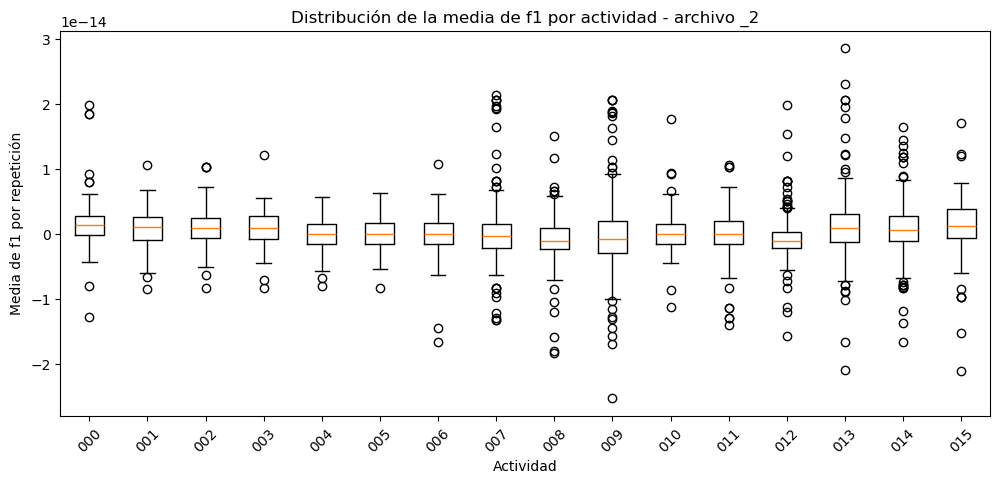

In [93]:
medias_por_repeticion = []

for numero in range(16):
    actividad = f"{numero:03d}"
    arreglo = datos[(actividad, "2")]
    for media in arreglo[:, :, 0].mean(axis=1):
        medias_por_repeticion.append({"actividad": actividad, "media_canal_0": media})

medias_por_repeticion = pd.DataFrame(medias_por_repeticion)

grupos = [
    medias_por_repeticion.loc[
        medias_por_repeticion["actividad"] == f"{numero:03d}", "media_canal_0"
    ]
    for numero in range(16)
]

plt.figure(figsize=(12, 5))
plt.boxplot(grupos, labels=[f"{numero:03d}" for numero in range(16)], showfliers=True)
plt.xlabel("Actividad")
plt.ylabel("Media de f1 por repetición")
plt.title("Distribución de la media de f1 por actividad - archivo _2")
plt.xticks(rotation=45)
plt.show()

El boxplot resume la distribución de cada actividad y permite comparar su posición central, dispersión y posibles valores extremos. Se observan diferencias entre algunas actividades, pero también cajas que ocupan zonas similares. Esto confirma que una única característica no separará perfectamente las 16 clases.

Los puntos fuera de los bigotes deben revisarse, pero no eliminarse automáticamente: podrían representar variaciones reales en la ejecución del movimiento o participantes con distinta movilidad. Antes de preparar el modelo se deberá comprobar si corresponden a errores de medición, repeticiones vacías o movimientos válidos.

Este resultado describe únicamente la media de `f1`; no debe generalizarse automáticamente a `f2`, `f3`, `f4`, `f5`, `pitch3` ni a los canales de `_1`. La conclusión válida es metodológica: el boxplot muestra cómo comparar actividades y localizar repeticiones que requieren revisión. La evaluación completa de valores extremos deberá aplicarse numéricamente a todos los canales antes de entrenar el clasificador.

## 10. Análisis multivariado: interacción entre dos canales

### ¿Qué se hará y para qué?

El análisis multivariado estudia más de una variable al mismo tiempo. En este bloque se calcula, para cada repetición, la media del canal 0 y la media del canal 1. Después se construye un diagrama de dispersión para observar si estas dos características permiten separar visualmente algunas actividades.

El cálculo se realiza con los dos archivos de sensor:

- Para `_1` se utilizan las 15 actividades cuyo archivo puede abrirse. La actividad 014 no se incluye porque `014_1.npy` está dañado.
- Para `_2` se utilizan las 16 actividades porque todos sus archivos son válidos.

Aunque se procesan todas las actividades disponibles, la gráfica muestra solamente cuatro: 000, 001, 007 y 015. Se eligieron actividades presentes en ambos sensores para que la comparación sea justa. Mostrar las 16 clases simultáneamente produciría cientos de puntos, colores y etiquetas superpuestas; eso dificultaría distinguir los grupos. La selección de cuatro actividades se utiliza únicamente para hacer legible la visualización y no significa que las demás se excluyan del análisis general o del futuro modelo.

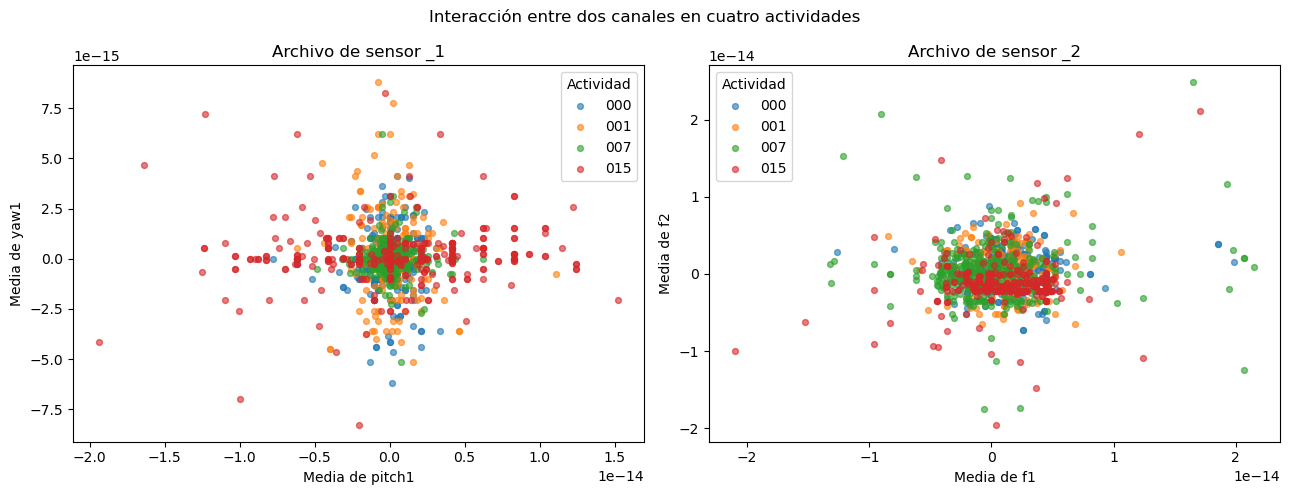

In [94]:
# Lista donde se guardará una fila por cada repetición disponible.
interacciones = []

# Se recorren los arreglos que pudieron cargarse correctamente.
# La llave contiene el número de actividad y el archivo de sensor.
for (actividad, sensor), arreglo in sorted(datos.items()):

    # Cada elemento de "arreglo" es una repetición con forma (880, 6).
    for repeticion in arreglo:

        # Se resumen los canales 0 y 1 mediante su media.
        # También se conservan la actividad y el sensor para poder agruparlos.
        interacciones.append({
            "actividad": actividad,
            "sensor": sensor,
            "media_canal_0": repeticion[:, 0].mean(),
            "media_canal_1": repeticion[:, 1].mean(),
        })

# La lista se convierte en una tabla: cada fila representa una repetición.
interacciones = pd.DataFrame(interacciones)

# Se eligen cuatro actividades disponibles en ambos sensores.
actividades_mostradas = ["000", "001", "007", "015"]

# Se crean dos gráficas: una para _1 y otra para _2.
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))

for eje, sensor in zip(ejes, ["1", "2"]):
    nombre_canal_0 = channel_names[sensor][0]
    nombre_canal_1 = channel_names[sensor][1]
    for actividad in actividades_mostradas:

        # Se seleccionan únicamente las repeticiones de la actividad y sensor actuales.
        parte = interacciones[
            (interacciones["actividad"] == actividad)
            & (interacciones["sensor"] == sensor)
        ]

        # Cada punto corresponde a una repetición completa.
        eje.scatter(
            parte["media_canal_0"],
            parte["media_canal_1"],
            s=18,
            alpha=0.6,
            label=actividad,
        )

    eje.set_xlabel(f"Media de {nombre_canal_0}")
    eje.set_ylabel(f"Media de {nombre_canal_1}")
    eje.set_title(f"Archivo de sensor _{sensor}")
    eje.legend(title="Actividad")

fig.suptitle("Interacción entre dos canales en cuatro actividades")
plt.tight_layout()
plt.show()

### Interpretación del resultado

Cada punto representa una repetición completa. En `_1`, su posición depende de las medias de `pitch1` y `yaw1`; en `_2`, depende de las medias de `f1` y `f2`. Los colores identifican las cuatro actividades seleccionadas y las dos gráficas permiten comparar la separación visual obtenida con cada par de variables.

En ambas gráficas existen zonas compartidas por diferentes actividades. Esto significa que las medias de solo dos canales no separan claramente todos los movimientos. Por lo tanto, un clasificador construido únicamente con estas dos características tendría dificultades para distinguir ciertas clases.

Este resultado orienta la siguiente etapa: será necesario combinar información de los seis canales y calcular más de una característica por repetición, por ejemplo desviación estándar, mínimo, máximo, rango y otras medidas de variación. También deberá evaluarse si conviene construir modelos separados para `_1` y `_2` o combinar ambos conjuntos. Esa decisión no se toma todavía porque primero se debe resolver el archivo `014_1.npy` y comparar formalmente el desempeño de ambas opciones.

## 11. Correlación entre canales en los dos archivos de sensor

### ¿Qué se hará y para qué?

La matriz de correlación permite identificar canales que tienden a cambiar juntos. Una correlación cercana a 1 representa una relación positiva fuerte; una cercana a -1 representa una relación negativa fuerte; y una cercana a 0 indica poca relación lineal. Detectar relaciones altas ayuda a reconocer variables que podrían contener información parcialmente repetida.

En los mapas de calor se usa la convención habitual: **rojo para las correlaciones positivas** y **azul para las negativas**. Los tonos cercanos al blanco representan relaciones próximas a cero. Esta elección de colores se conserva en las dos matrices.

Se construye una matriz independiente para cada archivo de sensor. Para `_1` se utilizan las 15 actividades válidas y para `_2` se utilizan las 16. No se mezclan ambos archivos en una sola matriz porque primero interesa conocer si sus relaciones internas son semejantes o diferentes.

Cada archivo contiene millones de puntos temporales. Para mantener el cálculo sencillo, se toma un punto de cada 50 de manera uniforme en todas las actividades disponibles. Esto reduce el volumen sin seleccionar solamente una actividad. La matriz final sigue siendo de 6 × 6 porque sus filas y columnas representan los seis canales; las actividades son las observaciones utilizadas para calcular esas relaciones, no los ejes de la matriz.

Correlación del archivo de sensor _1


,pitch1,yaw1,roll1,pitch2,yaw2,roll2
pitch1,1.00,-0.02,-0.08,0.52,0.02,0.08
yaw1,-0.02,1.00,0.00,-0.04,0.23,0.02
roll1,-0.08,0.00,1.00,-0.05,-0.08,0.02
pitch2,0.52,-0.04,-0.05,1.00,0.02,0.02
yaw2,0.02,0.23,-0.08,0.02,1.00,0.23
roll2,0.08,0.02,0.02,0.02,0.23,1.00


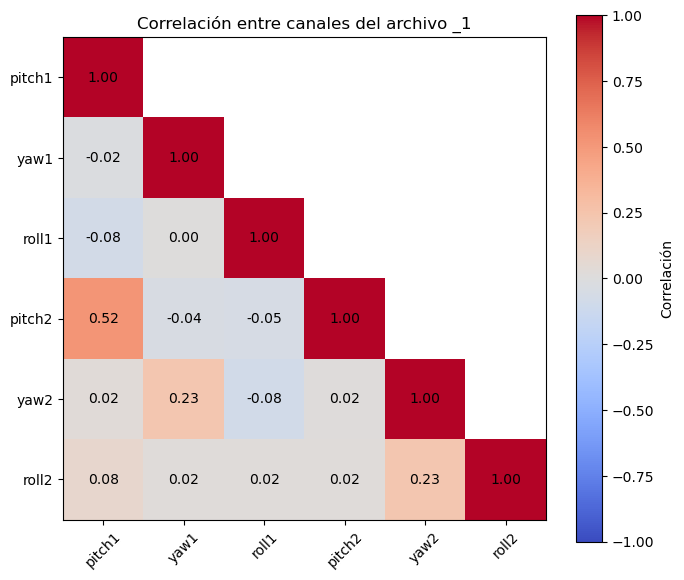

Correlación del archivo de sensor _2


,f1,f2,f3,f4,f5,pitch3
f1,1.00,0.75,0.79,0.79,0.80,0.03
f2,0.75,1.00,0.88,0.86,0.81,-0.03
f3,0.79,0.88,1.00,0.91,0.86,-0.03
f4,0.79,0.86,0.91,1.00,0.87,-0.03
f5,0.80,0.81,0.86,0.87,1.00,0.03
pitch3,0.03,-0.03,-0.03,-0.03,0.03,1.00


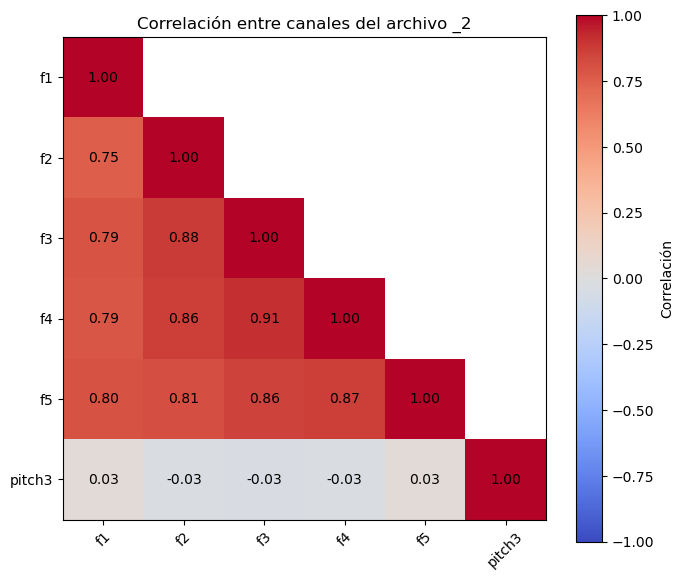

In [95]:
# Diccionario donde se guardará una matriz de correlación por sensor.
correlaciones = {}

# Se analiza _1 y _2 por separado.
for sensor in ["1", "2"]:
    partes_correlacion = []

    # Se recorren solamente los arreglos válidos del sensor actual.
    for (actividad, sensor_archivo), arreglo in sorted(datos.items()):
        if sensor_archivo != sensor:
            continue

        # Se unen repeticiones y tiempos para obtener una fila por punto temporal.
        puntos = arreglo.reshape(-1, 6)

        # Se toma un punto de cada 50 para reducir el tamaño del cálculo.
        muestra = puntos[::50]
        partes_correlacion.append(muestra)

    # Se juntan las muestras de todas las actividades disponibles.
    tabla_sensor = pd.DataFrame(
        np.vstack(partes_correlacion),
        columns=channel_names[sensor],
    )

    # Se calcula y guarda la matriz del sensor actual.
    correlaciones[sensor] = tabla_sensor.corr()

# Se muestran primero los valores numéricos de cada matriz.
for sensor, matriz in correlaciones.items():
    print(f"Correlación del archivo de sensor _{sensor}")
    display(matriz.round(2))

    # La mitad superior se oculta porque repite los mismos valores.
    mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
    matriz_inferior = np.ma.array(matriz, mask=mascara)

    # Se construye un mapa de calor sencillo usando solamente Matplotlib.
    plt.figure(figsize=(7, 6))
    # coolwarm coloca las correlaciones positivas en rojo y las negativas en azul.
    imagen = plt.imshow(matriz_inferior, cmap="coolwarm", vmin=-1, vmax=1)
    plt.xticks(range(6), channel_names[sensor], rotation=45)
    plt.yticks(range(6), channel_names[sensor])

    # Se escriben los valores únicamente en la diagonal y parte inferior.
    for i in range(6):
        for j in range(i + 1):
            plt.text(j, i, f"{matriz.iloc[i, j]:.2f}", ha="center", va="center")

    plt.colorbar(imagen, label="Correlación")
    plt.title(f"Correlación entre canales del archivo _{sensor}")
    plt.tight_layout()
    plt.show()

### Interpretación del resultado

Las dos matrices muestran comportamientos diferentes. En `_1`, la mayoría de las correlaciones son débiles. La relación más visible aparece entre `pitch1` y `pitch2`, con aproximadamente 0.52; también aparecen relaciones menores, cercanas a 0.23, entre `yaw1` y `yaw2` y entre `yaw2` y `roll2`.

En `_2`, `f1`, `f2`, `f3`, `f4` y `f5` presentan correlaciones positivas altas, aproximadamente entre 0.75 y 0.91. Esto indica que tienden a cambiar juntos y que parte de su información puede estar relacionada. `pitch3` mantiene correlaciones cercanas a cero con los demás, por lo que parece aportar un comportamiento más independiente.

La diferencia entre las matrices confirma que no conviene tratar `_1` y `_2` como si fueran intercambiables. Sus canales presentan relaciones internas distintas y podrían requerir análisis o modelos separados. Tampoco se deben eliminar canales únicamente con base en esta gráfica, porque una correlación global puede ocultar diferencias útiles entre actividades específicas.

Para el futuro modelo, estas matrices sirven como diagnóstico inicial de redundancia. La selección definitiva de canales deberá basarse en el desempeño de clasificación. Además, la correlación analiza relaciones lineales entre puntos, pero no conserva el orden temporal; por ello, después será necesario probar características por repetición y métodos que aprovechen la secuencia de 880 puntos.

# Paso 3. Evaluación de la calidad de los datos

La guía recomienda revisar problemas que podrían afectar las etapas posteriores: faltantes, infinitos, duplicados, ceros, desbalance y archivos que no puedan procesarse.

## 12. Archivos con errores, faltantes e infinitos

Los valores faltantes e infinitos pueden impedir cálculos o generar resultados incorrectos. Por ello se revisan todos los archivos válidos y también se presenta nuevamente cualquier archivo que no haya podido cargarse.

In [96]:
columnas_calidad = ["archivo", "estado", "faltantes", "infinitos"]
display(inventario[columnas_calidad])

print("Archivos con error:", (inventario["estado"] == "error").sum())
print("Valores faltantes en archivos válidos:", int(inventario["faltantes"].fillna(0).sum()))
print("Valores infinitos en archivos válidos:", int(inventario["infinitos"].fillna(0).sum()))

,archivo,estado,faltantes,infinitos
0,000_1.npy,correcto,0.0,0.0
1,000_2.npy,correcto,0.0,0.0
2,001_1.npy,correcto,0.0,0.0
3,001_2.npy,correcto,0.0,0.0
4,002_1.npy,correcto,0.0,0.0
5,002_2.npy,correcto,0.0,0.0
6,003_1.npy,correcto,0.0,0.0
7,003_2.npy,correcto,0.0,0.0
8,004_1.npy,correcto,0.0,0.0
9,004_2.npy,correcto,0.0,0.0


Archivos con error: 1
Valores faltantes en archivos válidos: 0
Valores infinitos en archivos válidos: 0


El archivo `014_1.npy` no puede cargarse como un arreglo NumPy válido. Por ello, no debe usarse silenciosamente ni sustituirse con datos inventados. Para los análisis que requieren las 16 actividades se utilizó el sensor 2, cuyos 16 archivos sí son válidos.

Esta decisión también afecta el desarrollo del modelo: mientras no se recupere el archivo dañado, el sensor 2 ofrece el conjunto más completo y consistente para construir una primera clasificación de las 16 actividades. Si después se desea combinar ambos sensores, será necesario volver a descargar o reparar `014_1.npy`.

## 13. Proporción de ceros y repeticiones completamente vacías

Además de buscar valores faltantes, se debe comprobar si existen datos formados por ceros. Un cero aislado puede ser una medición válida, pero una repetición completa con sus 880 puntos temporales y 6 canales en cero no contiene información sobre el movimiento.

Esta revisión se realiza por actividad y por sensor. Se calcula el porcentaje total de ceros y se cuenta cuántas repeticiones están completamente vacías. El objetivo es identificar observaciones que podrían confundir al clasificador, ya que diferentes actividades tendrían exactamente la misma señal sin movimiento.

In [97]:
calidad = []

for (actividad, sensor), arreglo in sorted(datos.items()):
    calidad.append({
        "actividad": actividad,
        "sensor": sensor,
        "porcentaje_ceros": 100 * np.mean(arreglo == 0),
        "repeticiones_solo_ceros": int(np.all(arreglo == 0, axis=(1, 2)).sum()),
    })

calidad = pd.DataFrame(calidad)
display(calidad.round(3))

,actividad,sensor,porcentaje_ceros,repeticiones_solo_ceros
0,000,1,0.000,0
1,000,2,0.000,0
2,001,1,3.302,7
3,001,2,3.302,7
4,002,1,0.375,1
5,002,2,0.375,1
6,003,1,0.000,0
7,003,2,0.000,0
8,004,1,4.007,11
9,004,2,3.833,11


### Interpretación de la revisión de ceros

La columna `porcentaje_ceros` indica qué proporción de cada archivo está formada por ceros. La columna `repeticiones_solo_ceros` cuenta las repeticiones en las que todos los valores son cero.

En el sensor 2 se encontraron **68 repeticiones completamente en cero**. La actividad 011 presenta la mayor cantidad, con 16, seguida de la actividad 012 con 13 y la actividad 004 con 11. Otras actividades no presentan ninguna repetición vacía.

Estas observaciones no deben pasar directamente al modelo porque no representan el comportamiento de los canales durante un movimiento. Antes de eliminarlas se debe confirmar con la documentación del dataset si los ceros representan capturas fallidas, relleno o periodos válidos sin movimiento. Si se confirma que son registros vacíos, deberán retirarse antes de dividir los datos en entrenamiento y prueba.

## 14. Búsqueda sencilla de repeticiones duplicadas

Las repeticiones duplicadas pueden hacer que el conjunto parezca más grande y variado de lo que realmente es. También pueden producir **fuga de información** si una copia queda en entrenamiento y otra copia idéntica queda en prueba, provocando una evaluación demasiado optimista del clasificador.

Para revisar este problema se crea una huella digital de cada repetición completa. Dos repeticiones se consideran duplicadas solamente cuando coinciden exactamente en los 880 puntos temporales y los 6 canales. Después se cuentan las huellas repetidas dentro de cada actividad y sensor.

In [98]:
def huella(repeticion):
    """Crea una etiqueta corta para comparar repeticiones completas."""
    return hashlib.md5(np.ascontiguousarray(repeticion).tobytes()).hexdigest()

duplicados = []
for (actividad, sensor), arreglo in sorted(datos.items()):
    huellas = pd.Series([huella(rep) for rep in arreglo])
    duplicados.append({
        "actividad": actividad,
        "sensor": sensor,
        "repeticiones": len(huellas),
        "duplicados": int(huellas.duplicated().sum()),
    })

duplicados = pd.DataFrame(duplicados)
display(duplicados)
print("Total de duplicados dentro de cada archivo:", duplicados["duplicados"].sum())

,actividad,sensor,repeticiones,duplicados
0,000,1,232,54
1,000,2,232,54
2,001,1,212,19
3,001,2,212,19
4,002,1,267,96
5,002,2,267,96
6,003,1,250,50
7,003,2,250,50
8,004,1,287,10
9,004,2,287,10


Total de duplicados dentro de cada archivo: 1349


### Interpretación de la revisión de duplicados

La tabla muestra el número de repeticiones disponibles y cuántas son copias exactas de una repetición anterior del mismo archivo. Las repeticiones parecidas, pero no idénticas, no se cuentan como duplicadas.

Se encontraron **716 duplicados en los archivos del sensor 2**. Las mayores cantidades aparecen en las actividades 015, 002, 012 y 014. Parte de estos duplicados podría relacionarse con las repeticiones completamente en cero, aunque también existen señales no vacías repetidas exactamente.

Antes del modelado se debe investigar el origen de estas copias. Si son duplicados generados durante el procesamiento, conviene conservar una sola repetición. Si representan ejecuciones reales registradas por separado, se debe evitar que copias idénticas queden en conjuntos diferentes. Esta precaución permitirá que las métricas reflejen la capacidad del modelo para clasificar movimientos nuevos y no su capacidad para memorizar registros repetidos.

# Conclusiones

- Los archivos válidos presentan una estructura consistente de 880 puntos temporales y 6 canales por repetición.
- La cantidad de repeticiones cambia entre actividades, por lo que existe cierto desbalance de clases.
- Las señales, histogramas y boxplots muestran diferencias entre movimientos, aunque también hay traslape.
- El análisis de interacción y correlación indica que los canales contienen relaciones que podrían aprovecharse en una etapa posterior.
- Los archivos `_1` y `_2` presentan estructuras de correlación diferentes; por ello, todavía no se deben mezclar automáticamente para entrenar un solo modelo.
- El principal problema de calidad detectado es el archivo `014_1.npy`, que está dañado. El archivo `014_2.npy` sí permite conservar la actividad 014 en el análisis.
- Los valores extremos deben investigarse antes de decidir si se eliminan, pues pueden representar variabilidad real del movimiento.

## Siguientes pasos

1. Confirmar con el diccionario del dataset el significado físico de cada canal.
2. Recuperar o volver a descargar `014_1.npy`.
3. Preparar una tabla de características por repetición, por ejemplo media, desviación estándar, mínimo y máximo.
4. Separar entrenamiento y prueba de forma estratificada para conservar la proporción de las 16 actividades.